In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Packages

In [ ]:
!pip install deap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 6.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import PIL
import random
from sklearn.model_selection import cross_val_score

from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Reshape, Input, Conv2D, MaxPooling2D, Flatten, Dense, GRU
from tensorflow.keras.models import Model
import seaborn as sns
import glob
import sklearn.metrics as metrics
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, roc_curve, roc_auc_score,auc
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, SeparableConv2D, BatchNormalization, Activation, Dense, Flatten, MaxPooling2D
from tensorflow.keras.layers import Add
from keras.layers import BatchNormalization
from keras.layers import ELU
from tensorflow.keras.layers import ReLU
import sys
from google.colab import files
import pandas as pd
from sklearn.preprocessing import label_binarize
import time
import numpy as np
import PIL
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Reshape, Input, Conv2D, MaxPooling2D, Flatten,  GRU
from tensorflow.keras.models import Model
import seaborn as sns
import glob
import sklearn.metrics as metrics
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Add
from keras.layers import BatchNormalization
from keras.layers import ELU
from tensorflow.keras.layers import ReLU
import sys
from google.colab import files
import pandas as pd
from sklearn.preprocessing import label_binarize
import time
from tensorflow.keras.applications import InceptionV3, ResNet50, EfficientNetB0, DenseNet201, InceptionResNetV2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import (
    VGG16, ResNet50, MobileNetV2, EfficientNetB0, EfficientNetB3,
    DenseNet121, Xception, NASNetMobile, InceptionV3, ConvNeXtTiny
)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from itertools import combinations
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from sklearn.decomposition import PCA
# from deap import base, creator, tools, algorithms





#Dataset

In [ ]:
# Load the .npy files
x_train = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/x_train_224.npy')
x_test = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/x_test_224.npy')
y_train = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_train.npy')
y_test = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_test.npy')
x_train = x_train.astype('float16')
x_test = x_test.astype('float16')
y_train = y_train.astype('float16')
y_test = y_test.astype('float16')
# Print the shapes
print("x_train.shape:", x_train.shape)
print("y_train.shape:", y_train.shape)
print("x_test.shape:", x_test.shape)
print("y_test.shape:", y_test.shape)


x_train.shape: (4056, 224, 224, 3)
y_train.shape: (4056, 6)
x_test.shape: (461, 224, 224, 3)
y_test.shape: (461, 6)


In [ ]:
num_classes=6
class_names = np.array(['ACK', 'BCC','MEL','NEV','SCC','SEK'])

#GoogleNet--60

In [ ]:
# Assuming x_train is a NumPy array
x_train_resized = tf.image.resize(x_train, (299, 299)).numpy()
x_test_resized = tf.image.resize(x_test, (299, 299)).numpy()
x_train1 = x_train_resized
x_test1 = x_test_resized

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


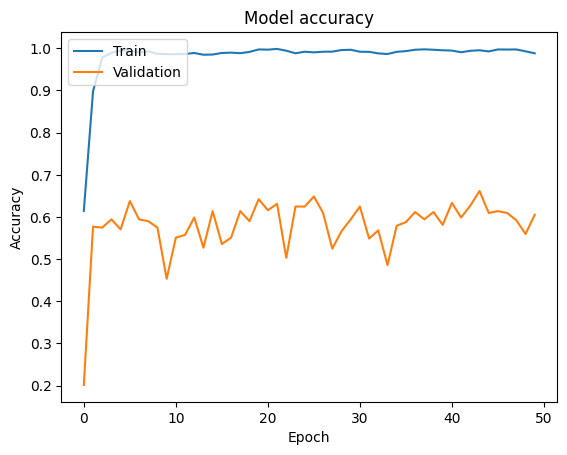

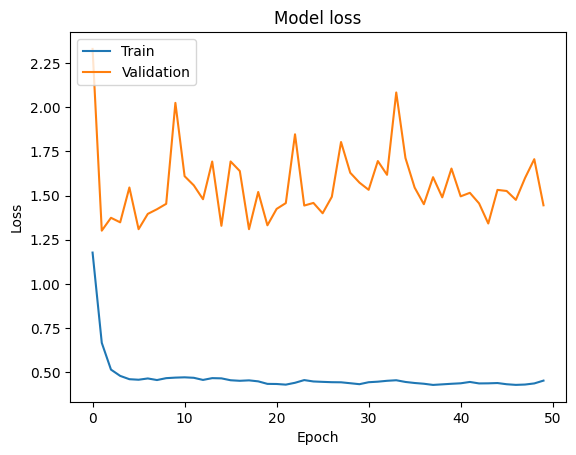

15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 451ms/step
Confusion Matrix:
[[ 76  62   0   1   4   3]
 [ 14 150   0   2   3   0]
 [  0   4   5   1   0   1]
 [  1  16   0  22   1   9]
 [  2  32   0   2   3   0]
 [  5  17   0   2   0  23]]


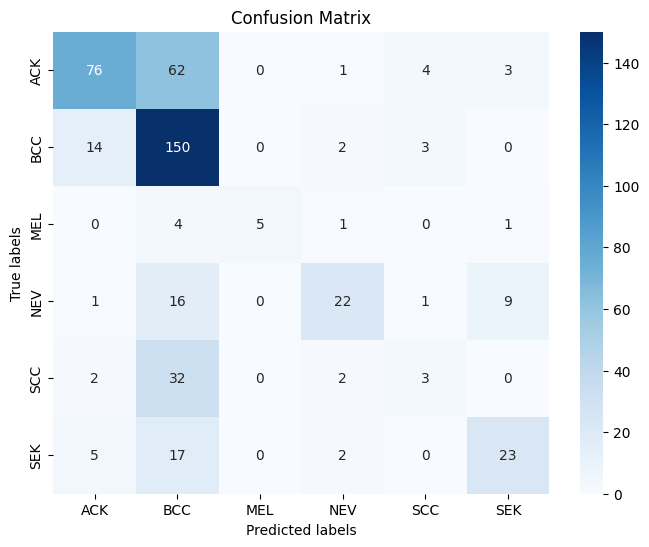


Classification Report:
              precision    recall  f1-score   support

           0     0.7755    0.5205    0.6230       146
           1     0.5338    0.8876    0.6667       169
           2     1.0000    0.4545    0.6250        11
           3     0.7333    0.4490    0.5570        49
           4     0.2727    0.0769    0.1200        39
           5     0.6389    0.4894    0.5542        47

    accuracy                         0.6052       461
   macro avg     0.6590    0.4797    0.5243       461
weighted avg     0.6313    0.6052    0.5825       461



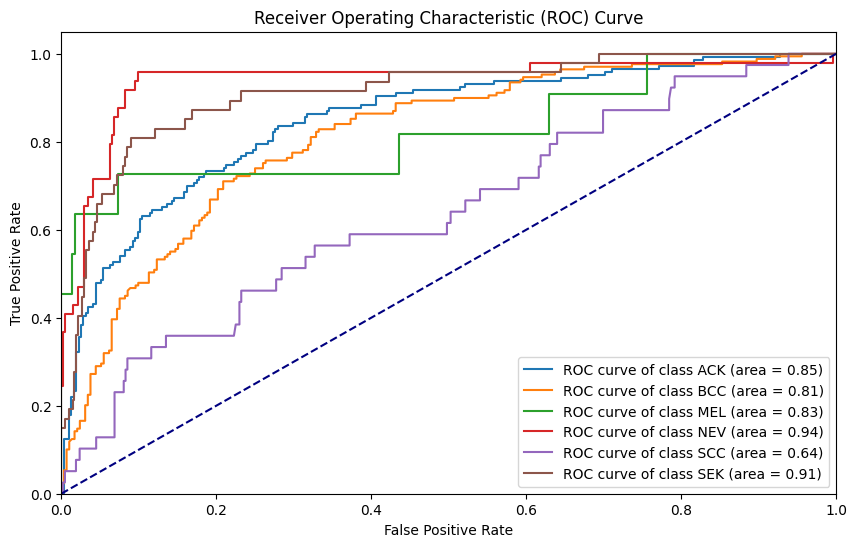

AUC: 0.824
AUC: 0.829


In [ ]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay


# Define a function to create and compile the InceptionV3 model
def create_model(learning_rate=0.001, dropout_rate=0.25):
    # Download InceptionV3 model weights
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

    # Save the model weights to a file
    # base_model.save_weights('gnet.weights.h5')

    for layer in base_model.layers[-20:]:
        layer.trainable = True  # Freeze all layers


    # Add your custom classifier on top (can be a few Dense layers)
    # For example:
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
#     x = Reshape((-1, 1024))(x)

#     # # Define the GRU layer for sequential processing of image features
#     gru = GRU(512)(x)
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust num_classes to your dataset's number of classes


    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with a given learning rate
    # optimizer = tf.keras.optimizers.AdamW(learning_rate = 1e-4,weight_decay=1e-4)
    #  Adam(learning_rate=learning_rate)
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
    initial_learning_rate=1e-3
    lr_schedule = ExponentialDecay(initial_learning_rate, decay_steps=1000, decay_rate=0.96, staircase=True)
    optimizer = tf.keras.optimizers.AdamW(learning_rate = 1e-4,weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss= loss_fn, metrics=['accuracy'])

    return model

final_model = create_model()
history = final_model.fit(x_train1,y_train, epochs=50, batch_size=32, validation_data=(x_test1,y_test), verbose=0)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/gnet/training_history_gnet_pad.npy", history.history)
# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/gnet/pad_gnet.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/gnet/x_test_prob_gnet_pad.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/gnet/x_test_pred_gnet_pad.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded
x_train_prob=model.predict(x_train1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/gnet/x_train_prob_gnet_pad.npy",x_train_prob)
x_train_pred=np.argmax(x_train_prob,axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/gnet/x_train_pred_gnet_pad.npy",x_train_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


# Densenet201--69

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


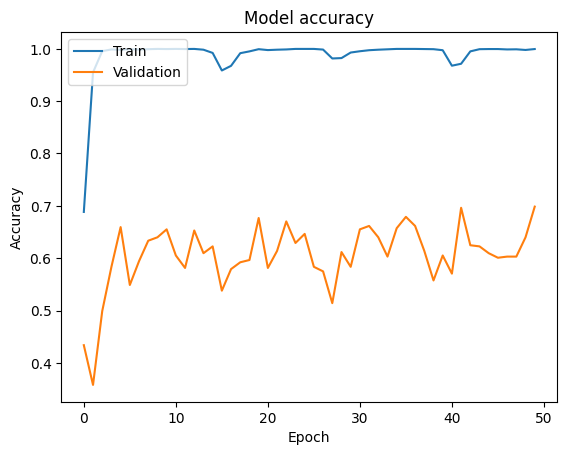

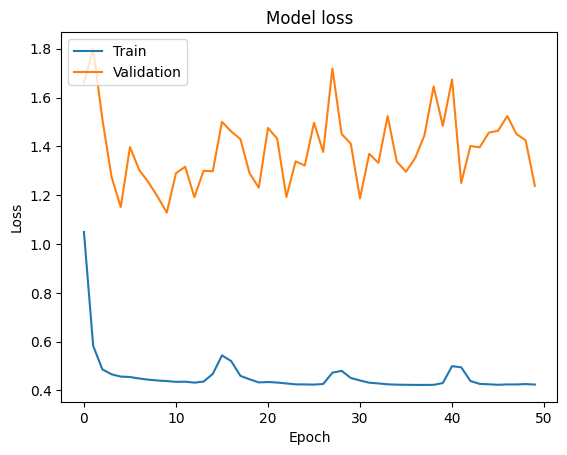

15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step
Confusion Matrix:
[[103  28   0   1   3  11]
 [ 16 142   0   6   4   1]
 [  1   0   7   1   0   2]
 [  1   4   0  31   2  11]
 [  3  30   0   2   4   0]
 [  4   4   0   4   0  35]]


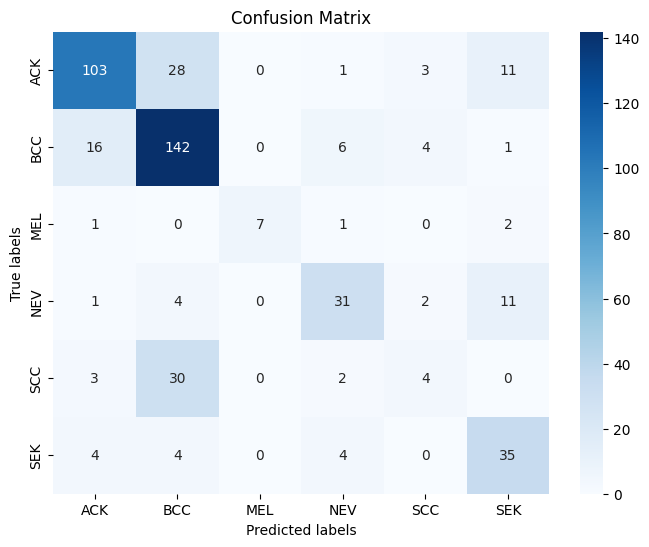


Classification Report:
              precision    recall  f1-score   support

           0     0.8047    0.7055    0.7518       146
           1     0.6827    0.8402    0.7533       169
           2     1.0000    0.6364    0.7778        11
           3     0.6889    0.6327    0.6596        49
           4     0.3077    0.1026    0.1538        39
           5     0.5833    0.7447    0.6542        47

    accuracy                         0.6985       461
   macro avg     0.6779    0.6103    0.6251       461
weighted avg     0.6877    0.6985    0.6826       461



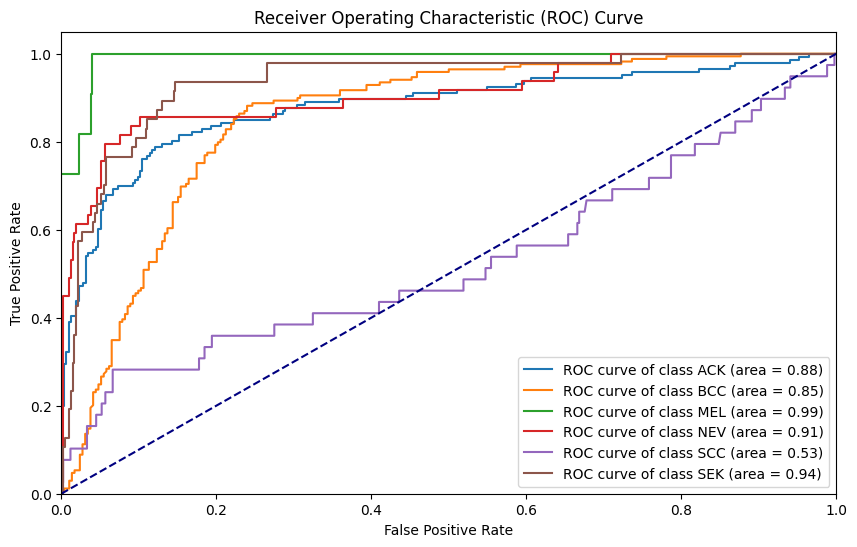

AUC: 0.837
AUC: 0.849


In [ ]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay


# Define a function to create and compile the InceptionV3 model
def create_model(learning_rate=0.001, dropout_rate=0.25):
    # Download InceptionV3 model weights
    base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Save the model weights to a file
    # base_model.save_weights('gnet.weights.h5')

    for layer in base_model.layers[100:150]:
        layer.trainable = True  # Freeze all layers


    # Add your custom classifier on top (can be a few Dense layers)
    # For example:
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
#     x = Reshape((-1, 1024))(x)

#     # # Define the GRU layer for sequential processing of image features
#     gru = GRU(512)(x)
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust num_classes to your dataset's number of classes


    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with a given learning rate
    # optimizer = tf.keras.optimizers.AdamW(learning_rate = 1e-4,weight_decay=1e-4)
    #  Adam(learning_rate=learning_rate)
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
    initial_learning_rate=1e-3
    lr_schedule = ExponentialDecay(initial_learning_rate, decay_steps=1000, decay_rate=0.96, staircase=True)
    optimizer = tf.keras.optimizers.AdamW(learning_rate = 1e-4,weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss= loss_fn, metrics=['accuracy'])

    return model

final_model = create_model()
history = final_model.fit(x_train,y_train, epochs=50, batch_size=32, validation_data=(x_test,y_test), verbose=0)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/dnet/training_history_dnet_pad.npy", history.history)
# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/dnet/pad_dnet.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/dnet/x_test_prob_dnet_pad.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/dnet/x_test_pred_dnet_pad.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded
x_train_prob=model.predict(x_train)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/dnet/x_train_prob_dnet_pad.npy",x_train_prob)
x_train_pred=np.argmax(x_train_prob,axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/dnet/x_train_pred_dnet_pad.npy",x_train_pred)
# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


# MobilenetV2--55

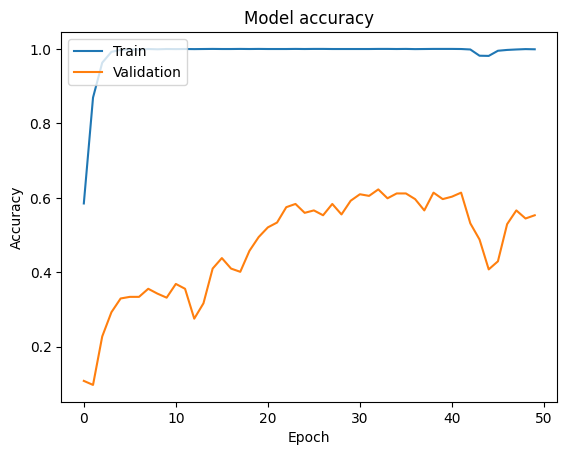

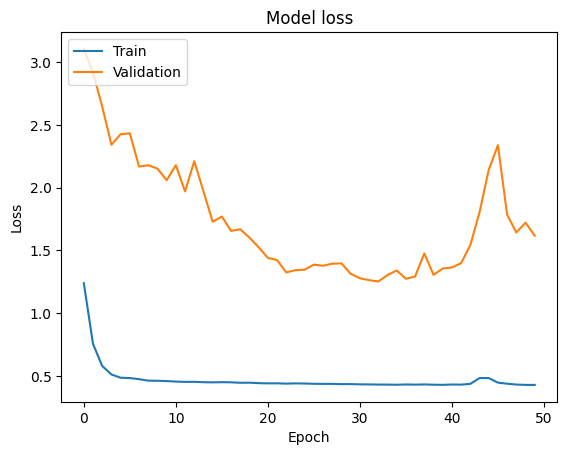

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step
Confusion Matrix:
[[ 53  73   1   1  13   5]
 [  8 139   0   2  17   3]
 [  0   1   6   1   0   3]
 [  2   9   0  27   1  10]
 [  5  27   0   2   4   1]
 [  5  10   3   3   0  26]]


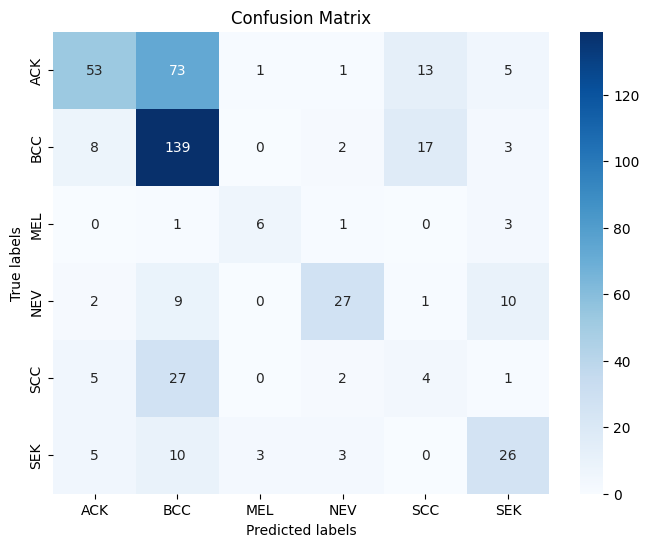


Classification Report:
              precision    recall  f1-score   support

           0     0.7260    0.3630    0.4840       146
           1     0.5367    0.8225    0.6495       169
           2     0.6000    0.5455    0.5714        11
           3     0.7500    0.5510    0.6353        49
           4     0.1143    0.1026    0.1081        39
           5     0.5417    0.5532    0.5474        47

    accuracy                         0.5531       461
   macro avg     0.5448    0.4896    0.4993       461
weighted avg     0.5856    0.5531    0.5375       461



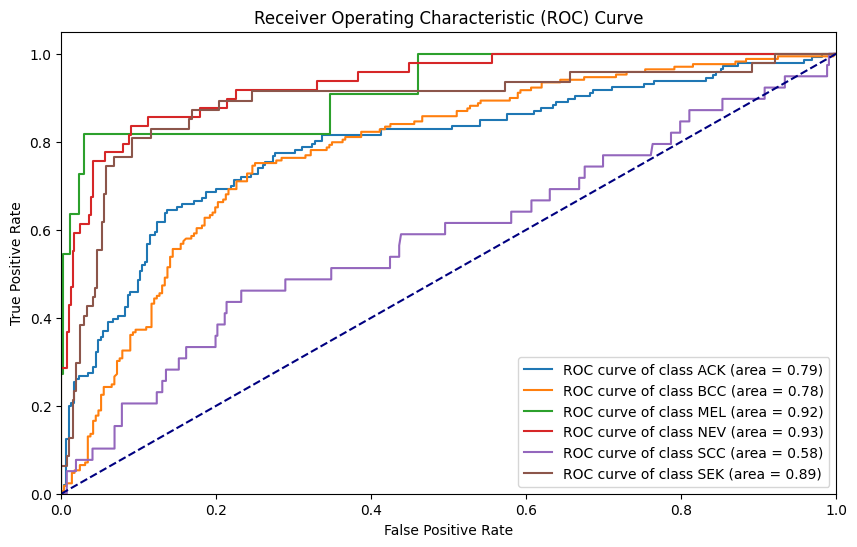

AUC: 0.809
AUC: 0.817


In [ ]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay


# Define a function to create and compile the InceptionV3 model
def create_model(learning_rate=0.001, dropout_rate=0.25):
    # Download InceptionV3 model weights
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Save the model weights to a file
    # base_model.save_weights('gnet.weights.h5')

    for layer in base_model.layers:
        layer.trainable = True  # Freeze all layers


    # Add your custom classifier on top (can be a few Dense layers)
    # For example:
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = BatchNormalization()(x)  # Add BatchNorm
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)  # Add another BatchNorm
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust num_classes to your dataset's number of classes


    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with a given learning rate
    # optimizer = tf.keras.optimizers.AdamW(learning_rate = 1e-4,weight_decay=1e-4)
    #  Adam(learning_rate=learning_rate)
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
    initial_learning_rate=1e-4
    lr_schedule = ExponentialDecay(initial_learning_rate, decay_steps=5000, decay_rate=0.96, staircase=True)
    optimizer = tf.keras.optimizers.AdamW(learning_rate = 1e-4,weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss= loss_fn, metrics=['accuracy'])

    return model

final_model = create_model()
history = final_model.fit(x_train,y_train, epochs=50, batch_size=32, validation_data=(x_test,y_test), verbose=0)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mnet/training_history_mnet_pad.npy", history.history)
# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/mnet/pad_mnet.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mnet/x_test_prob_mnet_pad.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mnet/x_test_pred_mnet_pad.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded
x_train_prob=model.predict(x_train)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mnet/x_train_prob_mnet_pad.npy",x_train_prob)
x_train_pred=np.argmax(x_train_prob,axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mnet/x_train_pred_mnet_pad.npy",x_train_pred)
# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


# InceptionResnetV2--60

In [ ]:
# Assuming x_train is a NumPy array
x_train_resized = tf.image.resize(x_train, (299, 299)).numpy()
x_test_resized = tf.image.resize(x_test, (299, 299)).numpy()
x_train1 = x_train_resized
x_test1 = x_test_resized

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


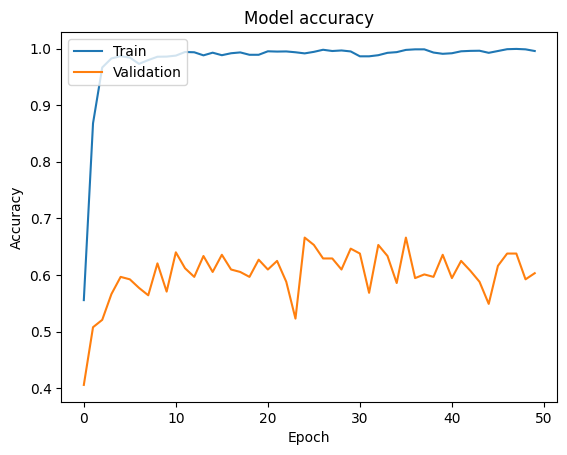

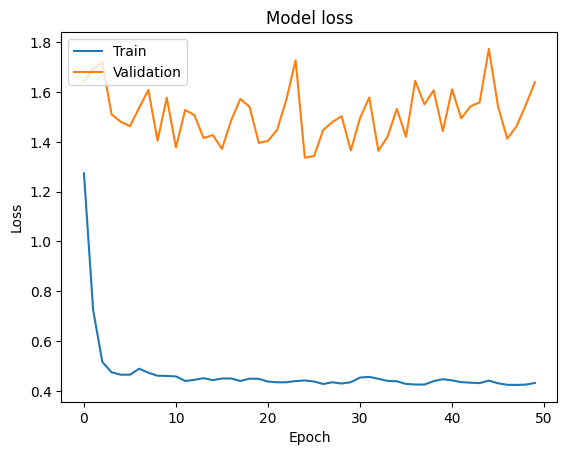

15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 818ms/step
Confusion Matrix:
[[ 65  75   0   2   0   4]
 [  9 153   0   4   1   2]
 [  0   4   3   3   0   1]
 [  3   7   0  30   0   9]
 [  0  34   0   2   2   1]
 [  1  14   1   6   0  25]]


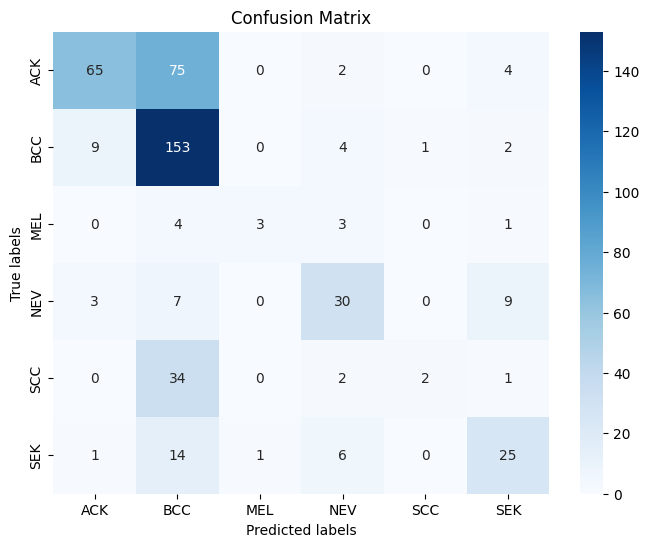


Classification Report:
              precision    recall  f1-score   support

           0     0.8333    0.4452    0.5804       146
           1     0.5331    0.9053    0.6711       169
           2     0.7500    0.2727    0.4000        11
           3     0.6383    0.6122    0.6250        49
           4     0.6667    0.0513    0.0952        39
           5     0.5952    0.5319    0.5618        47

    accuracy                         0.6030       461
   macro avg     0.6694    0.4698    0.4889       461
weighted avg     0.6622    0.6030    0.5711       461



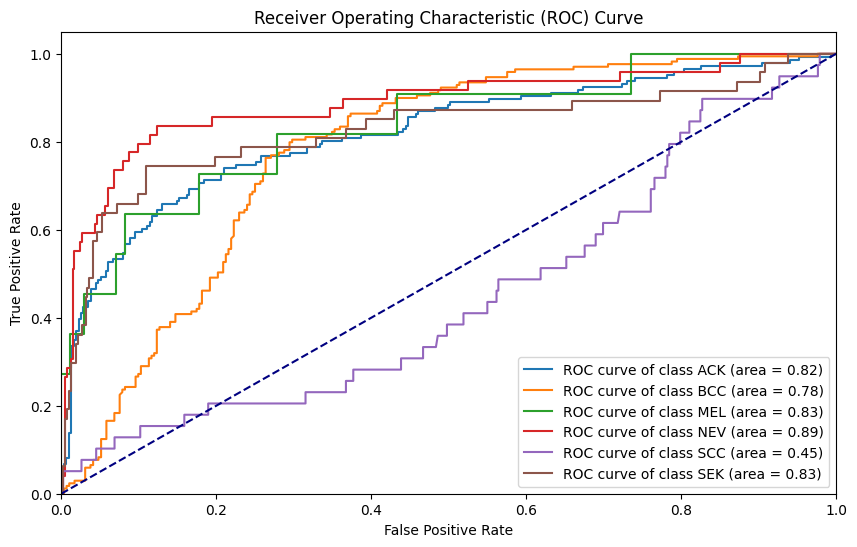

AUC: 0.764
AUC: 0.766


In [ ]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay


# Define a function to create and compile the InceptionV3 model
def create_model(learning_rate=0.001, dropout_rate=0.25):
    # Download InceptionV3 model weights
    base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

    # Save the model weights to a file
    # base_model.save_weights('gnet.weights.h5')

    for layer in base_model.layers[:200]:
        layer.trainable = False  # Freeze all layers


    # Add your custom classifier on top (can be a few Dense layers)
    # For example:
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
#     x = Reshape((-1, 1024))(x)

#     # # Define the GRU layer for sequential processing of image features
#     gru = GRU(512)(x)
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust num_classes to your dataset's number of classes


    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with a given learning rate
    # optimizer = tf.keras.optimizers.AdamW(learning_rate = 1e-4,weight_decay=1e-4)
    #  Adam(learning_rate=learning_rate)
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
    initial_learning_rate=1e-3
    lr_schedule = ExponentialDecay(initial_learning_rate, decay_steps=1000, decay_rate=0.96, staircase=True)
    optimizer = tf.keras.optimizers.AdamW(learning_rate = 1e-4,weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss= loss_fn, metrics=['accuracy'])

    return model

final_model = create_model()
history = final_model.fit(x_train1,y_train, epochs=50, batch_size=32, validation_data=(x_test1,y_test), verbose=0)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/irnet/training_history_irnet_pad.npy", history.history)
# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/irnet/pad_irnet.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/irnet/x_test_prob_irnet_pad.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/irnet/x_test_pred_irnet_pad.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded
x_train_prob=model.predict(x_train1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/irnet/x_train_prob_irnet_pad.npy",x_train_prob)
x_train_pred=np.argmax(x_train_prob,axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/irnet/x_train_pred_irnet_pad.npy",x_train_pred)
# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


#NasNetMobile--50

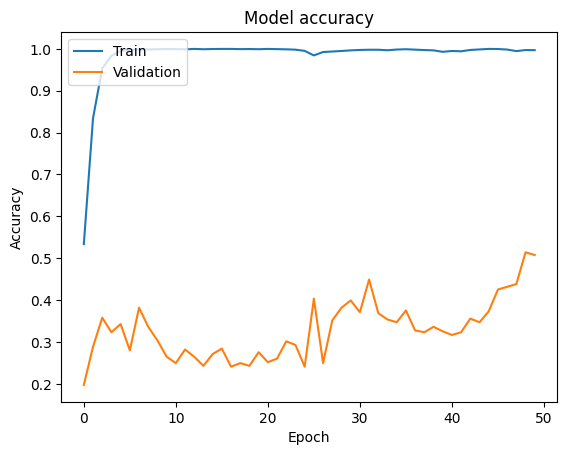

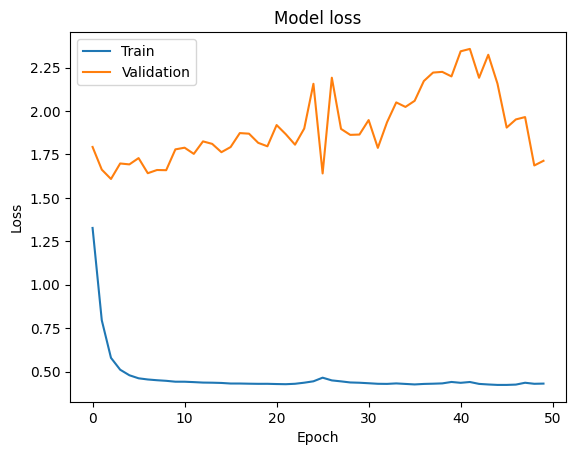

15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
Confusion Matrix:
[[79 43  2  3  2 17]
 [30 98  0 22  4 15]
 [ 0  2  1  0  0  8]
 [ 2  5  0 23  1 18]
 [ 8 21  0  5  1  4]
 [ 2  8  0  4  1 32]]


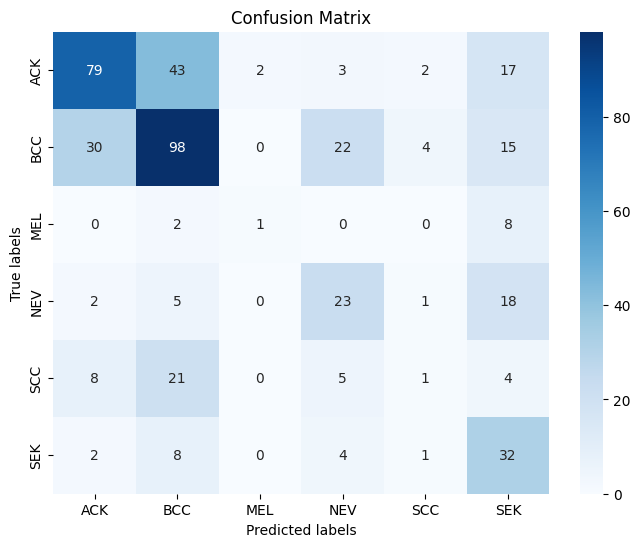


Classification Report:
              precision    recall  f1-score   support

           0     0.6529    0.5411    0.5918       146
           1     0.5537    0.5799    0.5665       169
           2     0.3333    0.0909    0.1429        11
           3     0.4035    0.4694    0.4340        49
           4     0.1111    0.0256    0.0417        39
           5     0.3404    0.6809    0.4539        47

    accuracy                         0.5076       461
   macro avg     0.3992    0.3980    0.3718       461
weighted avg     0.5047    0.5076    0.4944       461



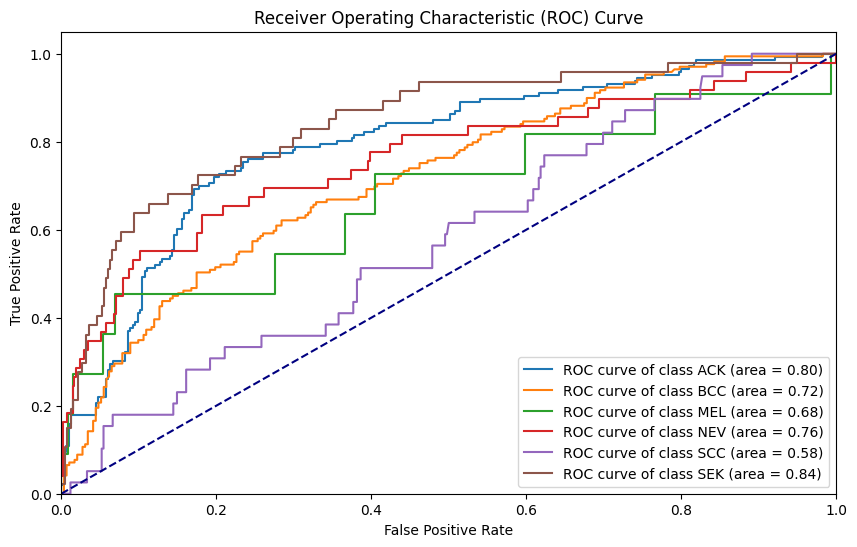

AUC: 0.729
AUC: 0.729


In [ ]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay


# Define a function to create and compile the InceptionV3 model
def create_model(learning_rate=0.001, dropout_rate=0.25):
    # Download InceptionV3 model weights
    base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Save the model weights to a file
    # base_model.save_weights('gnet.weights.h5')

    for layer in base_model.layers[:-50]:
        layer.trainable = True  # Freeze all layers


    # Add your custom classifier on top (can be a few Dense layers)
    # For example:
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
#     x = Reshape((-1, 1024))(x)

#     # # Define the GRU layer for sequential processing of image features
#     gru = GRU(512)(x)
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust num_classes to your dataset's number of classes


    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with a given learning rate
    # optimizer = tf.keras.optimizers.AdamW(learning_rate = 1e-4,weight_decay=1e-4)
    #  Adam(learning_rate=learning_rate)
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
    initial_learning_rate=1e-3
    lr_schedule = ExponentialDecay(initial_learning_rate, decay_steps=1000, decay_rate=0.96, staircase=True)
    optimizer = tf.keras.optimizers.AdamW(learning_rate = 1e-4,weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss= loss_fn, metrics=['accuracy'])

    return model

final_model = create_model()
history = final_model.fit(x_train,y_train, epochs=50, batch_size=32, validation_data=(x_test,y_test), verbose=0)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/nnet/training_history_nnet_pad.npy", history.history)
# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/nnet/pad_nnet.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/nnet/x_test_prob_nnet_pad.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/nnet/x_test_pred_nnet_pad.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded
x_train_prob=model.predict(x_train)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/nnet/x_train_prob_nnet_pad.npy",x_train_prob)
x_train_pred=np.argmax(x_train_prob,axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/nnet/x_train_pred_nnet_pad.npy",x_train_pred)
# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


# MBHCNN--75

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_96 (Conv2D)        │ (None, 224, 224, 32)   │            896 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_88    │ (None, 224, 224, 32)   │            128 │ conv2d_96[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_48          │ (None, 112, 112, 32)   │              0 │ batch_normalization_8… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_97 (Conv2D)        │ (None, 112, 112, 64)   │         18,496 │ max_pooling2d_48[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_89    │ (None, 112, 112, 64)   │            256 │ conv2d_97[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_49          │ (None, 56, 56, 64)     │              0 │ batch_normalization_8… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_67       │ (None, 56, 56, 64)     │          4,736 │ max_pooling2d_49[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_96    │ (None, 56, 56, 64)     │            256 │ separable_conv2d_67[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ elu_38 (ELU)              │ (None, 56, 56, 64)     │              0 │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_98 (Conv2D)        │ (None, 56, 56, 128)    │         73,856 │ max_pooling2d_49[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_100 (Conv2D)       │ (None, 112, 112, 32)   │          9,216 │ max_pooling2d_48[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_68       │ (None, 56, 56, 64)     │          4,736 │ elu_38[0][0]           │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_90    │ (None, 56, 56, 128)    │            512 │ conv2d_98[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_92    │ (None, 112, 112, 32)   │            128 │ conv2d_100[0][0]       │
│ (BatchNormalization) 

 Total params: 7,372,270 (28.12 MB)

 Trainable params: 7,362,542 (28.09 MB)

 Non-trainable params: 9,728 (38.00 KB)

Total number of layers: 108


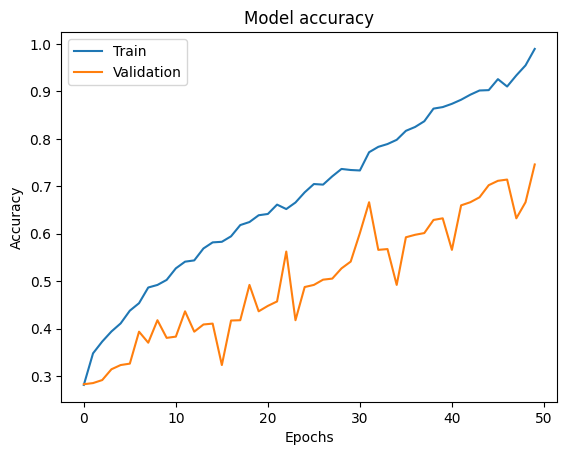

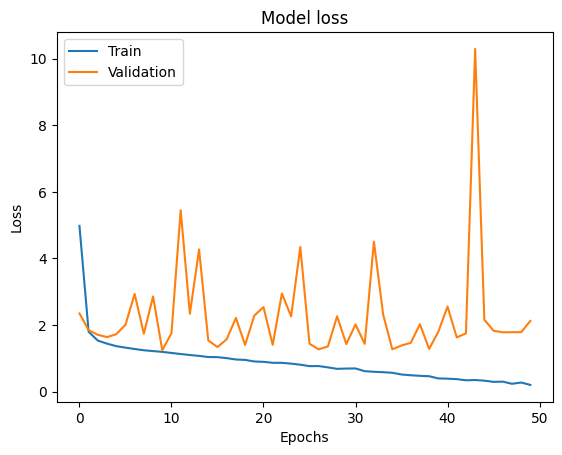

Confusion Matrix:
[[132   0   1   3   9   1]
 [ 25 102   1   7  31   3]
 [  1   0   9   1   0   0]
 [  3   2   0  42   0   2]
 [  7   0   0   3  27   2]
 [  3   2   0   4   1  37]]


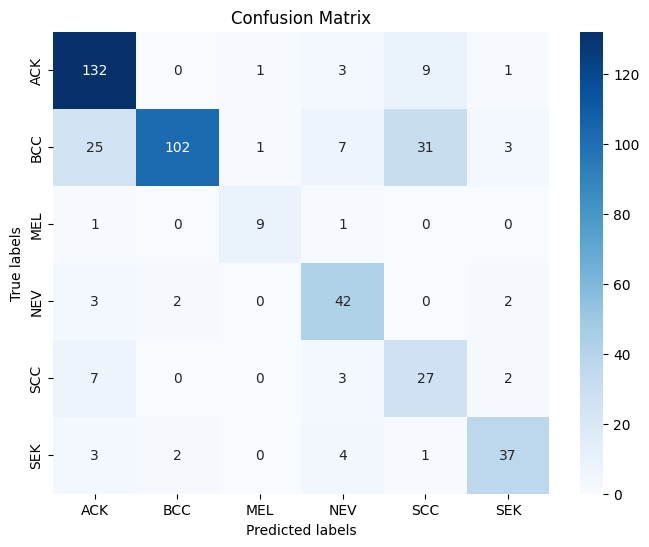


Classification Report:
              precision    recall  f1-score   support

           0     0.7719    0.9041    0.8328       146
           1     0.9623    0.6036    0.7418       169
           2     0.8182    0.8182    0.8182        11
           3     0.7000    0.8571    0.7706        49
           4     0.3971    0.6923    0.5047        39
           5     0.8222    0.7872    0.8043        47

    accuracy                         0.7570       461
   macro avg     0.7453    0.7771    0.7454       461
weighted avg     0.8086    0.7570    0.7618       461



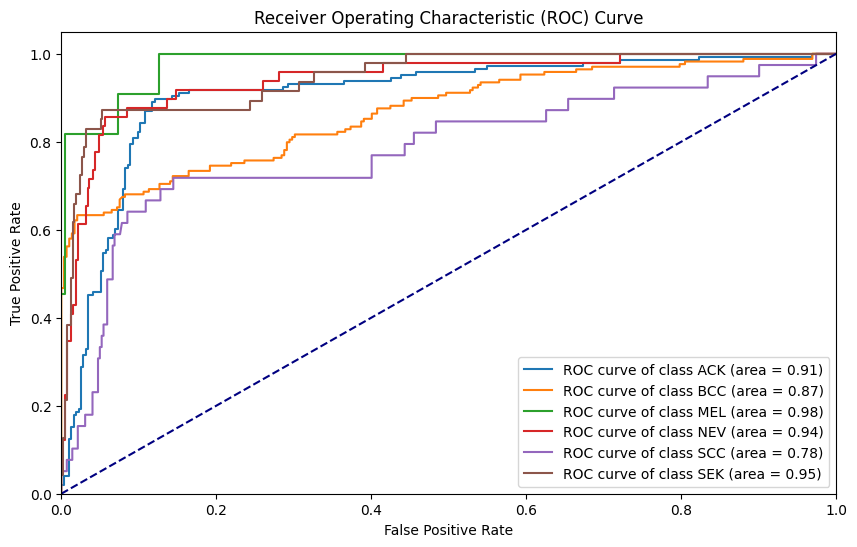

AUC: 0.909
AUC: 0.904


In [ ]:
# without GRU
def residual_block(x, filters, y=None):
    if y is None:
        y = x  # Set y to x if y is not provided
    shortcut = y
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ELU()(x)
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    return Add()([x, shortcut])

# Xception Block
def xception_block(x, filters):
    for _ in range(3):
        x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ELU()(x)
    return x

# Squeeze-Excite Block
def squeeze_excite_block(x, ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='elu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    return layers.multiply([x, se])

# MBConv Block (MobileNetV2)
def mbconv_block(x, filters, expansion_factor=6):
    input_filters = x.shape[-1]
    expanded_filters = input_filters * expansion_factor
    x = layers.Conv2D(expanded_filters, (1, 1), padding='same', activation='elu')(x)
    x = layers.DepthwiseConv2D((3, 3), padding='same')(x)
    x = layers.Conv2D(filters, (1, 1), padding='same', activation='linear')(x)
    return x

# Ghost Block
def ghost_block(x, filters):
    primary = layers.Conv2D(filters // 2, (1, 1), padding='same')(x)
    cheap_operation = layers.DepthwiseConv2D((3, 3), padding='same')(primary)
    return layers.concatenate([primary, cheap_operation])

# Fire Block (SqueezeNet)
def fire_block(x, squeeze_filters, expand_filters):
    x = layers.Conv2D(squeeze_filters, (1, 1), activation='elu')(x)
    expand1x1 = layers.Conv2D(expand_filters, (1, 1), activation='elu')(x)
    expand3x3 = layers.Conv2D(expand_filters, (3, 3), padding='same', activation='elu')(x)
    return layers.concatenate([expand1x1, expand3x3])

# Depthwise Separable Convolution Block
def dsc_block(x, filters):
    x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    return x

# Build the full model
def build_model(input_shape=(224, 224, 3), num_classes=6):
    inputs = layers.Input(shape=input_shape)

    # Initial Convolution and Pooling
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x32 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (64, 64, 32)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x32)
    x = layers.BatchNormalization()(x)
    x64 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (32, 32, 64)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x64)
    x = layers.BatchNormalization()(x)
    x128 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (16, 16, 128)

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x128)
    x = layers.BatchNormalization()(x)
    x256 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (08, 08, 256)

    # Block 1: Residual + MBConv + Depthwise Separable Convolution
    x1 = residual_block(x32, 32)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = mbconv_block(x1, 32)
    mbconv1 = Conv2D(64,(3,3),padding="same")(x1)
    mbconv1 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv1)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = dsc_block(x1,32)
    x1 = Conv2D(256, (3, 3), padding='same')(x1)
    x1 = BatchNormalization()(x1)
    x1 = layers.ReLU()(x1)

    # Block 2: Xception + res + dsc
    x2 = xception_block(x64, 64)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = residual_block(x2, 64,mbconv1)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = mbconv_block(x2, 64)
    x2 = Conv2D(256, (3, 3), padding='same')(x2)
    x2 = BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)

    # Block 3: SE + MBConv + Depthwise Separable Convolution
    x3 = squeeze_excite_block(x128)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = mbconv_block(x3, 128)
    mbconv3 = Conv2D(256,(3,3),padding="same")(x3)
    mbconv3 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv3)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = dsc_block(x3, 128)
    x3 = Conv2D(256, (3, 3), padding='same')(x3)
    x3 = BatchNormalization()(x3)
    x3 = layers.ReLU()(x3)

    # Block 4: MBConv + Residual + Depthwise Separable Convolution
    x4 = mbconv_block(x256, 256)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = residual_block(x4, 256,mbconv3)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = dsc_block(x4, 256)
    x4 = Conv2D(256, (3, 3), padding='same')(x4)
    x4 = BatchNormalization()(x4)
    x4 = layers.ReLU()(x4)

    # Concatenate all blocks
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x3=layers.MaxPooling2D(pool_size=(2, 2))(x3)
    concatenated = layers.concatenate([x1, x2, x3, x4], axis=-1)

    x = SeparableConv2D(1024, (3, 3), padding='same')(concatenated)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SeparableConv2D(1024, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)


    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    
    optimizer = Adam(learning_rate=0.00001)
    model.compile(optimizer=optimizer, loss= 'categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and compile the model
model = build_model(input_shape=(224, 224, 3), num_classes=6)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

total_layers = len(model.layers)
print("Total number of layers:", total_layers)

final_model = build_model(input_shape=(224, 224, 3), num_classes=6)
history = final_model.fit(x_train,y_train, epochs=50, batch_size=32, validation_data=(x_test,y_test), verbose=0)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/ccnn/training_history_ccnn_pad.npy", history.history)
# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/ccnn/pad_ccnngru.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/ccnn/x_test_prob_ccnn_pad.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/ccnn/x_test_pred_ccnn_pad.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded
x_train_prob=model.predict(x_train)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/ccnn/x_train_prob_ccnn_pad.npy",x_train_prob)
x_train_pred=np.argmax(x_train_prob,axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/ccnn/x_train_pred_ccnn_pad.npy",x_train_pred)
# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


#MBHCNNGRU--80

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_48 (Conv2D)        │ (None, 224, 224, 32)   │            896 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_44    │ (None, 224, 224, 32)   │            128 │ conv2d_48[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_24          │ (None, 112, 112, 32)   │              0 │ batch_normalization_4… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_49 (Conv2D)        │ (None, 112, 112, 64)   │         18,496 │ max_pooling2d_24[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_45    │ (None, 112, 112, 64)   │            256 │ conv2d_49[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_25          │ (None, 56, 56, 64)     │              0 │ batch_normalization_4… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_35       │ (None, 56, 56, 64)     │          4,736 │ max_pooling2d_25[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_52    │ (None, 56, 56, 64)     │            256 │ separable_conv2d_35[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ elu_20 (ELU)              │ (None, 56, 56, 64)     │              0 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_50 (Conv2D)        │ (None, 56, 56, 128)    │         73,856 │ max_pooling2d_25[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_52 (Conv2D)        │ (None, 112, 112, 32)   │          9,216 │ max_pooling2d_24[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_36       │ (None, 56, 56, 64)     │          4,736 │ elu_20[0][0]           │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_46    │ (None, 56, 56, 128)    │            512 │ conv2d_50[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_48    │ (None, 112, 112, 32)   │            128 │ conv2d_52[0][0]        │
│ (BatchNormalization) 

 Total params: 8,948,206 (34.13 MB)

 Trainable params: 8,938,478 (34.10 MB)

 Non-trainable params: 9,728 (38.00 KB)

Total number of layers: 109


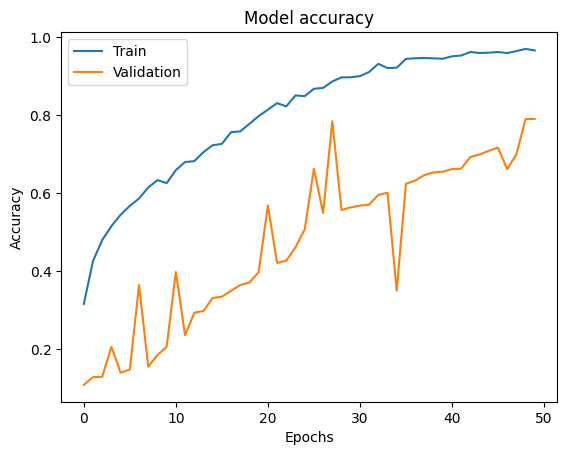

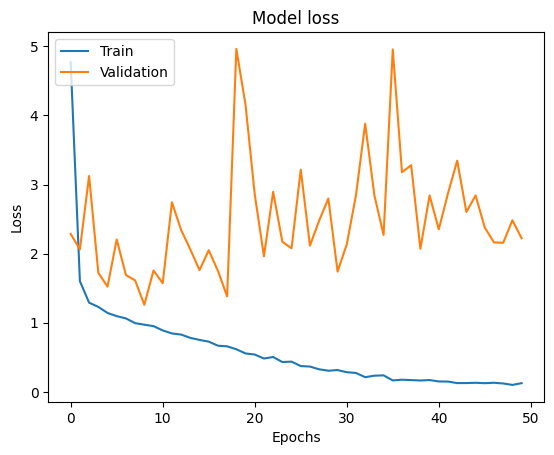

Confusion Matrix:
[[133   0   1   2   9   1]
 [ 21 116   1   5  24   2]
 [  1   0   9   1   0   0]
 [  3   0   0  44   0   2]
 [  5   0   0   3  30   1]
 [  2   2   0   3   0  40]]


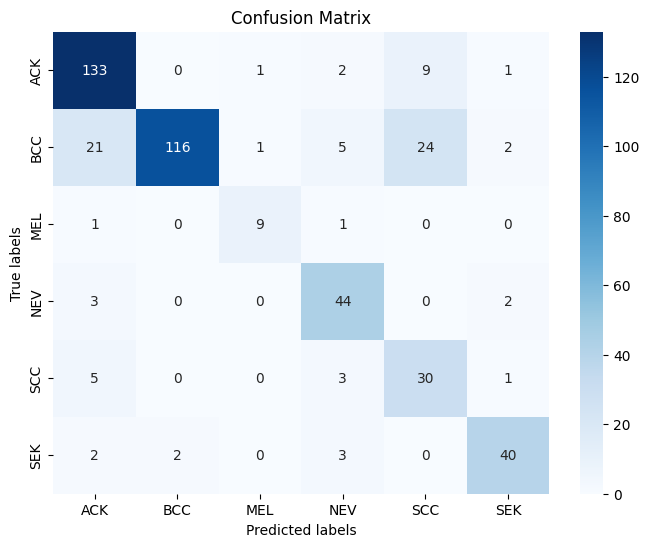


Classification Report:
              precision    recall  f1-score   support

           0     0.8061    0.9110    0.8553       146
           1     0.9831    0.6864    0.8084       169
           2     0.8182    0.8182    0.8182        11
           3     0.7586    0.8980    0.8224        49
           4     0.4762    0.7692    0.5882        39
           5     0.8696    0.8511    0.8602        47

    accuracy                         0.8069       461
   macro avg     0.7853    0.8223    0.7921       461
weighted avg     0.8448    0.8069    0.8116       461



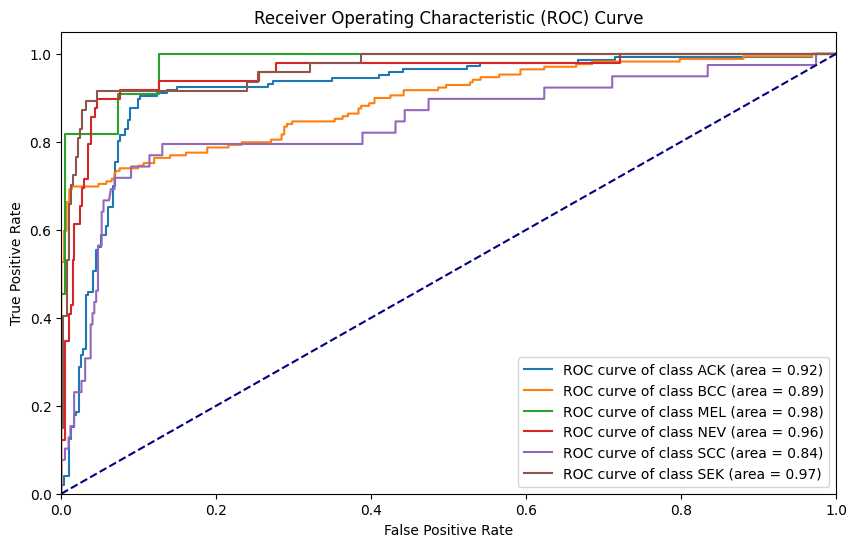

AUC: 0.930
AUC: 0.926


In [ ]:
# without GRU
def residual_block(x, filters, y=None):
    if y is None:
        y = x  # Set y to x if y is not provided
    shortcut = y
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ELU()(x)
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    return Add()([x, shortcut])

# Xception Block
def xception_block(x, filters):
    for _ in range(3):
        x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ELU()(x)
    return x

# Squeeze-Excite Block
def squeeze_excite_block(x, ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='elu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    return layers.multiply([x, se])

# MBConv Block (MobileNetV2)
def mbconv_block(x, filters, expansion_factor=6):
    input_filters = x.shape[-1]
    expanded_filters = input_filters * expansion_factor
    x = layers.Conv2D(expanded_filters, (1, 1), padding='same', activation='elu')(x)
    x = layers.DepthwiseConv2D((3, 3), padding='same')(x)
    x = layers.Conv2D(filters, (1, 1), padding='same', activation='linear')(x)
    return x

# Ghost Block
def ghost_block(x, filters):
    primary = layers.Conv2D(filters // 2, (1, 1), padding='same')(x)
    cheap_operation = layers.DepthwiseConv2D((3, 3), padding='same')(primary)
    return layers.concatenate([primary, cheap_operation])

# Fire Block (SqueezeNet)
def fire_block(x, squeeze_filters, expand_filters):
    x = layers.Conv2D(squeeze_filters, (1, 1), activation='elu')(x)
    expand1x1 = layers.Conv2D(expand_filters, (1, 1), activation='elu')(x)
    expand3x3 = layers.Conv2D(expand_filters, (3, 3), padding='same', activation='elu')(x)
    return layers.concatenate([expand1x1, expand3x3])

# Depthwise Separable Convolution Block
def dsc_block(x, filters):
    x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    return x

# Build the full model
def build_model(input_shape=(224, 224, 3), num_classes=6):
    inputs = layers.Input(shape=input_shape)

    # Initial Convolution and Pooling
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x32 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (64, 64, 32)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x32)
    x = layers.BatchNormalization()(x)
    x64 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (32, 32, 64)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x64)
    x = layers.BatchNormalization()(x)
    x128 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (16, 16, 128)

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x128)
    x = layers.BatchNormalization()(x)
    x256 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (08, 08, 256)

    # Block 1: Residual + MBConv + Depthwise Separable Convolution
    x1 = residual_block(x32, 32)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = mbconv_block(x1, 32)
    mbconv1 = Conv2D(64,(3,3),padding="same")(x1)
    mbconv1 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv1)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = dsc_block(x1,32)
    x1 = Conv2D(256, (3, 3), padding='same')(x1)
    x1 = BatchNormalization()(x1)
    x1 = layers.ReLU()(x1)

    # Block 2: Xception + res + dsc
    x2 = xception_block(x64, 64)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = residual_block(x2, 64,mbconv1)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = mbconv_block(x2, 64)
    x2 = Conv2D(256, (3, 3), padding='same')(x2)
    x2 = BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)

    # Block 3: SE + MBConv + Depthwise Separable Convolution
    x3 = squeeze_excite_block(x128)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = mbconv_block(x3, 128)
    mbconv3 = Conv2D(256,(3,3),padding="same")(x3)
    mbconv3 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv3)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = dsc_block(x3, 128)
    x3 = Conv2D(256, (3, 3), padding='same')(x3)
    x3 = BatchNormalization()(x3)
    x3 = layers.ReLU()(x3)

    # Block 4: MBConv + Residual + Depthwise Separable Convolution
    x4 = mbconv_block(x256, 256)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = residual_block(x4, 256,mbconv3)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = dsc_block(x4, 256)
    x4 = Conv2D(256, (3, 3), padding='same')(x4)
    x4 = BatchNormalization()(x4)
    x4 = layers.ReLU()(x4)

    # Concatenate all blocks
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x3=layers.MaxPooling2D(pool_size=(2, 2))(x3)
    concatenated = layers.concatenate([x1, x2, x3, x4], axis=-1)

    x = SeparableConv2D(1024, (3, 3), padding='same')(concatenated)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SeparableConv2D(1024, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)


    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    # x = layers.Dropout(0.5)(x)
    x = Reshape((-1,512))(x)
    gru = GRU(512)(x)
    x = layers.Dense(512, activation='relu')(gru)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    
    optimizer = Adam(learning_rate=0.00001)
    model.compile(optimizer=optimizer, loss= 'categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and compile the model
model = build_model(input_shape=(224, 224, 3), num_classes=6)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

total_layers = len(model.layers)
print("Total number of layers:", total_layers)

final_model = build_model(input_shape=(224, 224, 3), num_classes=6)
history = final_model.fit(x_train,y_train, epochs=50, batch_size=32, validation_data=(x_test,y_test), verbose=0)
# np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/ccnngru/training_history_ccnngru_pad.npy", history.history)
# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/ccnngru/pad_ccnngru.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/ccnngru/x_test_prob_ccnngru_pad.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/ccnngru/x_test_pred_ccnngru_pad.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded
x_train_prob=model.predict(x_train)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/ccnngru/x_train_prob_ccnngru_pad.npy",x_train_prob)
x_train_pred=np.argmax(x_train_prob,axis=1)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/ccnngru/x_train_pred_ccnngru_pad.npy",x_train_pred)
# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)





#SVM--78.52

Combination (0,): Accuracy = 0.5879
Combination (1,): Accuracy = 0.6746
Combination (2,): Accuracy = 0.4338
Combination (3,): Accuracy = 0.3449
Combination (4,): Accuracy = 0.5922
Combination (5,): Accuracy = 0.7050
Combination (0, 1): Accuracy = 0.5922
Combination (0, 2): Accuracy = 0.5683
Combination (0, 3): Accuracy = 0.5705
Combination (0, 4): Accuracy = 0.5727
Combination (0, 5): Accuracy = 0.7354
Combination (1, 2): Accuracy = 0.6746
Combination (1, 3): Accuracy = 0.6659
Combination (1, 4): Accuracy = 0.6009
Combination (1, 5): Accuracy = 0.7505
Combination (2, 3): Accuracy = 0.4035
Combination (2, 4): Accuracy = 0.5835
Combination (2, 5): Accuracy = 0.6811
Combination (3, 4): Accuracy = 0.5662
Combination (3, 5): Accuracy = 0.6811
Combination (4, 5): Accuracy = 0.7462
Combination (0, 1, 2): Accuracy = 0.6182
Combination (0, 1, 3): Accuracy = 0.6182
Combination (0, 1, 4): Accuracy = 0.5965
Combination (0, 1, 5): Accuracy = 0.7527
Combination (0, 2, 3): Accuracy = 0.5835
Combinati

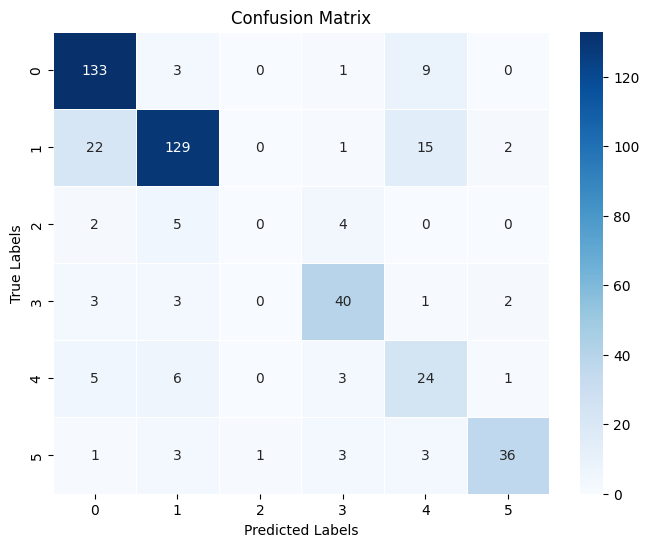


Multiclass ROC AUC Score: 0.8888


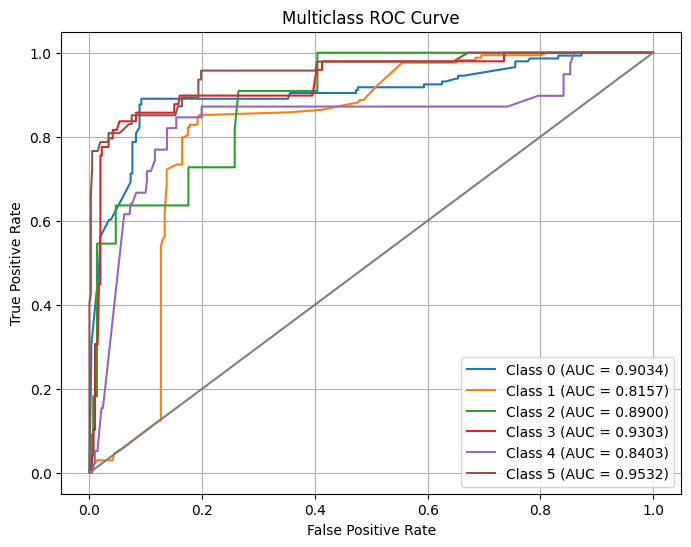

In [ ]:


# Load train and test predictions from all 6 models
model_paths = [
    "/content/drive/MyDrive/PAD_UFES_20/paper4/gnet/x_train_pred_gnet_pad.npy", "/content/drive/MyDrive/PAD_UFES_20/paper4/gnet/x_test_pred_gnet_pad.npy",
    "/content/drive/MyDrive/PAD_UFES_20/paper4/dnet/x_train_pred_dnet_pad.npy", "/content/drive/MyDrive/PAD_UFES_20/paper4/dnet/x_test_pred_dnet_pad.npy",
    "/content/drive/MyDrive/PAD_UFES_20/paper4/mnet/x_train_pred_mnet_pad.npy", "/content/drive/MyDrive/PAD_UFES_20/paper4/mnet/x_test_pred_mnet_pad.npy",
    "/content/drive/MyDrive/PAD_UFES_20/paper4/nnet/x_train_pred_nnet_pad.npy", "/content/drive/MyDrive/PAD_UFES_20/paper4/nnet/x_test_pred_nnet_pad.npy",
    "/content/drive/MyDrive/PAD_UFES_20/paper4/irnet/x_train_pred_irnet_pad.npy", "/content/drive/MyDrive/PAD_UFES_20/paper4/irnet/x_test_pred_irnet_pad.npy",
    "/content/drive/MyDrive/PAD_UFES_20/paper4/ccnngru/x_train_pred_ccnngru_pad.npy", "/content/drive/MyDrive/PAD_UFES_20/paper4/ccnngru/x_test_pred_ccnngru_pad.npy"

    ]

models = [np.load(path) for path in model_paths]

# Split into train & test sets
train_predictions = [models[i] for i in range(0, len(models), 2)]
test_predictions = [models[i] for i in range(1, len(models), 2)]

# Load true labels
y_train = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_train.npy')
y_test = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_test.npy')
y_train=np.argmax(y_train, axis=1)
y_test=np.argmax(y_test, axis=1)

# Get number of classes
# classes = np.unique(y_train)
# n_classes = len(classes)

# Find best combination of models
best_acc = 0
best_combination = None
best_svm = None

# Try all combinations of models (1 to 6 models combined)
for r in range(1, 7):
    for combo in combinations(range(6), r):
        # Stack selected models
        X_train = np.hstack([train_predictions[i].reshape(-1, 1) for i in combo])
        # print("\t X_train",X_train.shape)
        X_test = np.hstack([test_predictions[i].reshape(-1, 1) for i in combo])
        # print("\t X_test",X_test.shape)

        # Train SVM
        svm = SVC(kernel='linear', probability=True, decision_function_shape='ovr')  # One-vs-Rest (OvR) for multiclass
        svm.fit(X_train, y_test)

        # Evaluate accuracy
        y_pred = svm.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        print(f"Combination {combo}: Accuracy = {acc:.4f}")

        # Save the best model
        if acc > best_acc:
            best_acc = acc
            best_combination = combo
            best_svm = svm

print(f"\nBest Combination: {best_combination} with Accuracy = {best_acc:.4f}")


# Evaluate Best Model
X_test_best = np.hstack([test_predictions[i].reshape(-1, 1) for i in best_combination])

# Ensure 2D shape
if X_test_best.ndim == 1:
    X_test_best = X_test_best.reshape(-1, 1)  # Fix single-model issue

y_pred_best = best_svm.predict(X_test_best)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/svm/x_test_pred_svm_pad.npy",y_pred_best)
y_prob_best = best_svm.predict_proba(X_test_best)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/svm/x_test_prob_svm_pad.npy",y_prob_best)


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix
# Compute confusion matrix (if not already computed)
conf_matrix = confusion_matrix(y_test, y_pred_best)
n_classes=6
# Plot Confusion Matrix with Values
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", linewidths=0.5, cbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC AUC for Multiclass (One-vs-Rest)
classes = np.unique(y_test)  # Ensures classes are an array-like
# Binarize y_test for ROC AUC computation
y_test_bin = label_binarize(y_test, classes=classes)  # Binarize labels for multiclass AUC
roc_auc = roc_auc_score(y_test_bin, y_prob_best, multi_class='ovr')
print(f"\nMulticlass ROC AUC Score: {roc_auc:.4f}")

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_best[:, i])
    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc_score(y_test_bin[:, i], y_prob_best[:, i]):.4f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='-')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.grid()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Full model name mapping
model_names = {
    'M1': 'GoogleNet',
    'M2': 'DenseNet201',
    'M3': 'MobileNetV2',
    'M4': 'NASNet',
    'M5': 'InceptionResNetV2',
    'M6': 'PHMBCNNGRU'

}
# Your dictionary
data = {

    2: {59.22, 56.83, 57.05, 57.27, 73.54, 67.46, 66.59, 60.09, 75.05, 40.35, 58.35, 68.11, 56.62, 68.11, 74.62},
    3: {61.82, 61.82, 59.65, 75.27, 58.35, 53.36, 74.40, 58.79, 74.19, 73.97, 66.59, 60.30, 77.22, 60.74, 76.57, 77.44, 57.70, 74.84, 74.19, 76.14},
    4:{62.69, 64.21, 75.92, 59.87, 76.36, 77.66, 57.27, 75.27, 74.62, 76.79, 62.04, 77.22, 75.92, 78.52, 75.92},
    5:{63.99, 76.79, 75.92, 78.31, 76.57, 78.31},
    6:{77.87}
}

# Convert to DataFrame
rows = []
for key, values in data.items():
    for val in values:
        rows.append({'Key': key, 'Value': val})

df = pd.DataFrame(rows)

# Find the max value
max_val = df['Value'].max()

# Add color column
df['Color'] = df['Value'].apply(lambda x: 'red' if x == max_val else 'skyblue')

# Plot
plt.figure(figsize=(10,5), dpi=300)
for i, row in df.iterrows():
    plt.scatter(row['Key'], row['Value'], color=row['Color'], s=75)
                # , edgecolor='black')
    if row['Color'] == 'red':
        plt.text(row['Key'], row['Value'] + 0.4, f"{{M2,M4,M5,M6}} = {row['Value']}%",
                 ha='center', va='bottom', fontsize=12, color='red')
# Set x-axis to show only unique keys
plt.xticks(sorted(data.keys()), fontsize=10)
plt.yticks(fontsize=10)
# Combined legend text box
legend_text = "Legend:\n• Best Combination (red dot)\n\nModel Names:\n" + '\n'.join([f"{k} = {v}" for k, v in model_names.items()])
plt.gcf().text(0.79, 0.15, legend_text, fontsize=8.5, va='bottom', bbox=dict(facecolor='white', edgecolor='gray'))

# Labels & layout
# plt.title('Strip Plot (Highlight Highest Value)')
plt.xlabel("Number of Models in Combination", fontsize=10)
plt.ylabel("Accuracy (%)", fontsize=10)
plt.title("SVM classifier Accuracy Visualization on Model Combinations", fontsize=12, weight='bold')
# plt.xlabel('Key')
# plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#MLP


## feature extraction

In [ ]:
base_model = InceptionV3(weights="imagenet", include_top=False, pooling="avg")
X_train_gnet = base_model.predict(x_train)
X_test_gnet = base_model.predict(x_test)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_gnet_features.npy",X_train_gnet)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_gnet_features.npy",X_test_gnet)

base_model = DenseNet201(weights='imagenet', include_top=False, pooling='avg')
X_train_dnet = base_model.predict(x_train)
X_test_dnet = base_model.predict(x_test)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_dnet_features.npy",X_train_dnet)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_dnet_features.npy",X_test_dnet)

base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
X_train_mnet = base_model.predict(x_train)
X_test_mnet = base_model.predict(x_test)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_mnet_features.npy",X_train_mnet)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_mnet_features.npy",X_test_mnet)

from tensorflow.keras.preprocessing.image import smart_resize

# Resize function
def resize_images(images, target_size=(224, 224)):
    resized_images = np.array([smart_resize(img, target_size) for img in images])
    return resized_images

# Resize x_train and x_test
x_train_resized = resize_images(x_train)  # Shape becomes (4000, 224, 224, 3)
x_test_resized = resize_images(x_test)
base_model = NASNetMobile(weights='imagenet',
                          include_top=False, pooling='avg')
X_train_nnet = base_model.predict(x_train_resized)
X_test_nnet = base_model.predict(x_test_resized )
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_nnet_features.npy",X_train_nnet)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_nnet_features.npy",X_test_nnet)

base_model = InceptionResNetV2(weights='imagenet', include_top=False, pooling='avg')
X_train_irnet = base_model.predict(x_train)
X_test_irnet = base_model.predict(x_test)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_irnet_features.npy",X_train_irnet)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_irnet_features.npy",X_test_irnet)




87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 326ms/step
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 51s 216ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step


<ipython-input-6-0766d90278a0>:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 456ms/step
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 647ms/step
219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 27s 123ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 411ms/step


AttributeError: 'list' object has no attribute 'Model'

In [ ]:
# with GRU
def residual_block(x, filters, y=None):
    if y is None:
        y = x  # Set y to x if y is not provided
    shortcut = y
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ELU()(x)
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    return Add()([x, shortcut])

# Xception Block
def xception_block(x, filters):
    for _ in range(3):
        x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ELU()(x)
    return x

# Squeeze-Excite Block
def squeeze_excite_block(x, ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='elu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    return layers.multiply([x, se])

# MBConv Block (MobileNetV2)
def mbconv_block(x, filters, expansion_factor=6):
    input_filters = x.shape[-1]
    expanded_filters = input_filters * expansion_factor
    x = layers.Conv2D(expanded_filters, (1, 1), padding='same', activation='elu')(x)
    x = layers.DepthwiseConv2D((3, 3), padding='same')(x)
    x = layers.Conv2D(filters, (1, 1), padding='same', activation='linear')(x)
    return x

# Ghost Block
def ghost_block(x, filters):
    primary = layers.Conv2D(filters // 2, (1, 1), padding='same')(x)
    cheap_operation = layers.DepthwiseConv2D((3, 3), padding='same')(primary)
    return layers.concatenate([primary, cheap_operation])

# Fire Block (SqueezeNet)
def fire_block(x, squeeze_filters, expand_filters):
    x = layers.Conv2D(squeeze_filters, (1, 1), activation='elu')(x)
    expand1x1 = layers.Conv2D(expand_filters, (1, 1), activation='elu')(x)
    expand3x3 = layers.Conv2D(expand_filters, (3, 3), padding='same', activation='elu')(x)
    return layers.concatenate([expand1x1, expand3x3])

# Depthwise Separable Convolution Block
def dsc_block(x, filters):
    x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    return x

# Build the full model
def build_model(input_shape=(224, 224, 3), num_classes=6):
    inputs = layers.Input(shape=input_shape)

    # Initial Convolution and Pooling
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x32 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (64, 64, 32)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x32)
    x = layers.BatchNormalization()(x)
    x64 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (32, 32, 64)

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x64)
    x = layers.BatchNormalization()(x)
    x128 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (16, 16, 128)

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x128)
    x = layers.BatchNormalization()(x)
    x256 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (08, 08, 256)

    # Block 1: Residual + MBConv + Depthwise Separable Convolution
    x1 = residual_block(x32, 32)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = mbconv_block(x1, 32)
    mbconv1 = Conv2D(64,(3,3),padding="same")(x1)
    mbconv1 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv1)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = dsc_block(x1,32)
    x1 = Conv2D(256, (3, 3), padding='same')(x1)
    x1 = BatchNormalization()(x1)
    x1 = layers.ReLU()(x1)

    # Block 2: Xception + res + dsc
    x2 = xception_block(x64, 64)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = residual_block(x2, 64,mbconv1)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = mbconv_block(x2, 64)
    x2 = Conv2D(256, (3, 3), padding='same')(x2)
    x2 = BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)

    # Block 3: SE + MBConv + Depthwise Separable Convolution
    x3 = squeeze_excite_block(x128)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = mbconv_block(x3, 128)
    mbconv3 = Conv2D(256,(3,3),padding="same")(x3)
    mbconv3 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv3)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = dsc_block(x3, 128)
    x3 = Conv2D(256, (3, 3), padding='same')(x3)
    x3 = BatchNormalization()(x3)
    x3 = layers.ReLU()(x3)

    # Block 4: MBConv + Residual + Depthwise Separable Convolution
    x4 = mbconv_block(x256, 256)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = residual_block(x4, 256,mbconv3)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = dsc_block(x4, 256)
    x4 = Conv2D(256, (3, 3), padding='same')(x4)
    x4 = BatchNormalization()(x4)
    x4 = layers.ReLU()(x4)

    # Concatenate all blocks
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x3=layers.MaxPooling2D(pool_size=(2, 2))(x3)
    concatenated = layers.concatenate([x1, x2, x3, x4], axis=-1)

    x = SeparableConv2D(1024, (3, 3), padding='same')(concatenated)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SeparableConv2D(1024, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)


    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    # x = layers.Dropout(0.5)(x)
    x = Reshape((-1,512))(x)
    gru = GRU(512)(x)
    x = layers.Dense(512, activation='relu')(gru)
    # x = layers.Dropout(0.5)(x)
    # outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, x)
    return model
model = build_model()
X_train_ccnngru = model.predict(x_train)
X_test_ccnngru = model.predict(x_test)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_ccnngru_features.npy",X_train_ccnngru)
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_ccnngru_features.npy",X_test_ccnngru)



127/127 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


In [ ]:
X_train_gnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_gnet_features.npy')
X_test_gnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_gnet_features.npy')
X_train_dnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_dnet_features.npy')
X_test_dnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_dnet_features.npy')
X_train_mnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_mnet_features.npy')
X_test_mnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_mnet_features.npy')
X_train_nnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_nnet_features.npy')
X_test_nnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_nnet_features.npy')
X_train_irnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_irnet_features.npy')
X_test_irnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_irnet_features.npy')
X_train_ccnngru=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_ccnngru_features.npy')
X_test_ccnngru=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_ccnngru_features.npy')
# Concatenate Features
x_train_features = np.hstack((X_train_gnet,X_train_mnet,X_train_nnet,X_train_dnet,X_train_irnet,X_train_ccnngru))
x_test_features = np.hstack((X_test_gnet,X_test_mnet,X_test_nnet,X_test_dnet,X_test_irnet,X_test_ccnngru))
print("x_train_feature_shape",x_train_features.shape)
print("x_test_feature_shape",x_test_features.shape)
# Print total features after concatenation
print(f"Total features after concatenation: {x_train_features.shape[1]}")

x_train_feature_shape (4056, 8352)
x_test_feature_shape (461, 8352)
Total features after concatenation: 8352


In [ ]:
y_train = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_train.npy')
y_test = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_test.npy')

##on all the features--63.99

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


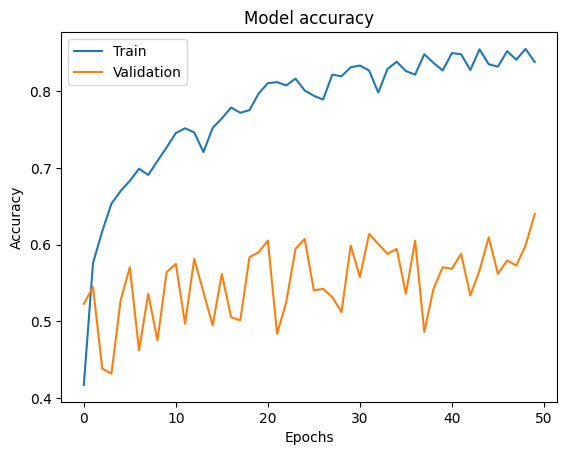

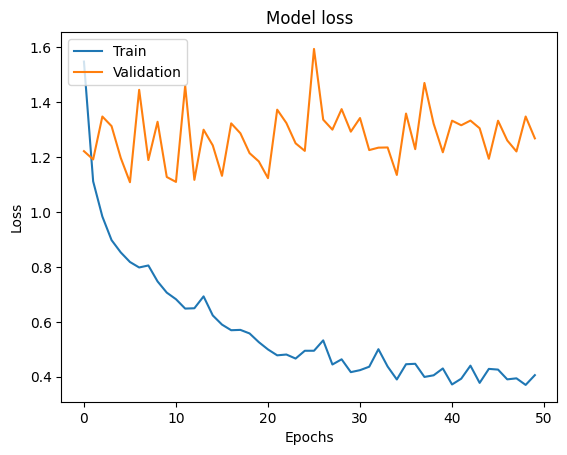

Confusion Matrix:
[[105  32   0   0   3   6]
 [ 24 124   0   4  15   2]
 [  0   0   6   0   0   5]
 [  3   3   2  29   1  11]
 [  7  21   0   1  10   0]
 [ 15   5   1   4   1  21]]


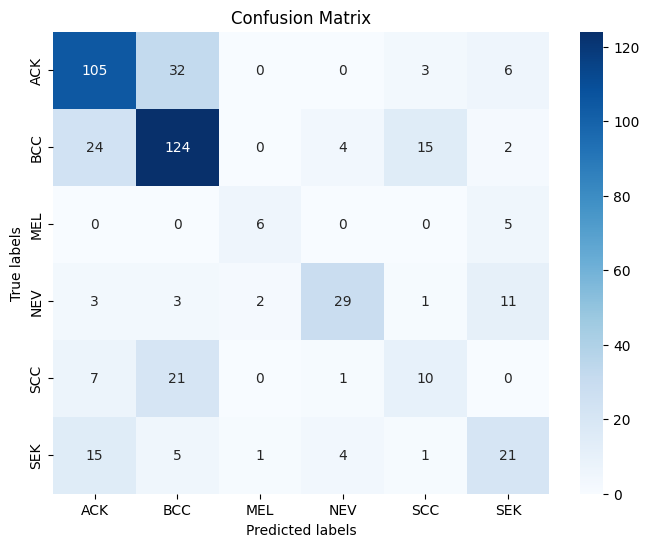


Classification Report:
              precision    recall  f1-score   support

           0     0.6818    0.7192    0.7000       146
           1     0.6703    0.7337    0.7006       169
           2     0.6667    0.5455    0.6000        11
           3     0.7632    0.5918    0.6667        49
           4     0.3333    0.2564    0.2899        39
           5     0.4667    0.4468    0.4565        47

    accuracy                         0.6399       461
   macro avg     0.5970    0.5489    0.5689       461
weighted avg     0.6345    0.6399    0.6348       461



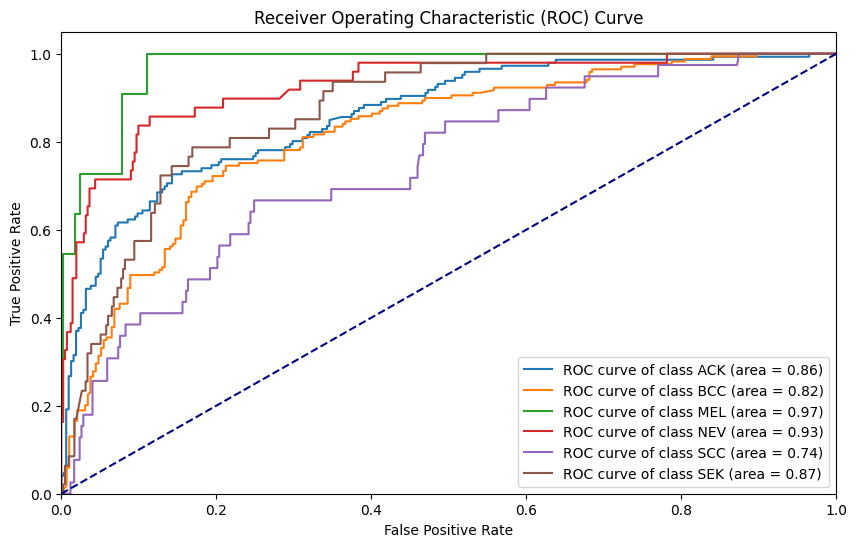

AUC: 0.861
AUC: 0.865


In [ ]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(8352,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(x_train_features, y_train, epochs=50, batch_size=32, validation_data=(x_test_features,y_test),verbose=0)


# plt.figure(figsize=(12, 5))
# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(x_test_features)  # Get prediction probabilities
np.save('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_prob_allfeatures_pad.npy',y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_pred_allfeatures_pad.npy',y_pred)

# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ---------------------- AUC & ROC Curve ------------------------
y_true = np.argmax(y_test, axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)



##PCA--58.79

In [ ]:
X_train_gnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_gnet_features.npy')
X_test_gnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_gnet_features.npy')
X_train_dnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_dnet_features.npy')
X_test_dnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_dnet_features.npy')
X_train_mnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_mnet_features.npy')
X_test_mnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_mnet_features.npy')
X_train_nnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_nnet_features.npy')
X_test_nnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_nnet_features.npy')
X_train_irnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_irnet_features.npy')
X_test_irnet=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_irnet_features.npy')
X_train_ccnngru=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_train_ccnngru_features.npy')
X_test_ccnngru=np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/X_test_ccnngru_features.npy')

# Concatenate Features
x_train_features = np.hstack((X_train_gnet,X_train_mnet,X_train_nnet,X_train_dnet,X_train_irnet,X_train_ccnngru))
x_test_features = np.hstack((X_test_gnet,X_test_mnet,X_test_nnet,X_test_dnet,X_test_irnet,X_test_ccnngru))
print("x_train_feature_shape",x_train_features.shape)
print("x_test_feature_shape",x_test_features.shape)
# Print total features after concatenation
print(f"Total features after concatenation: {x_train_features.shape[1]}")

x_train_feature_shape (4056, 8352)
x_test_feature_shape (461, 8352)
Total features after concatenation: 8352


Total features after PCA: 1951
x_train_features_pca (4056, 1951)
x_test_features_pca (461, 1951)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


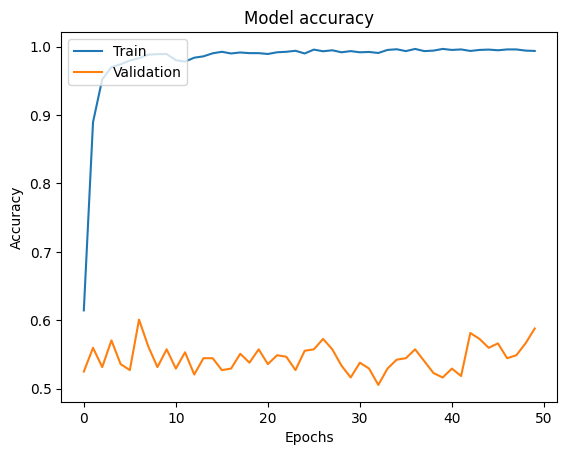

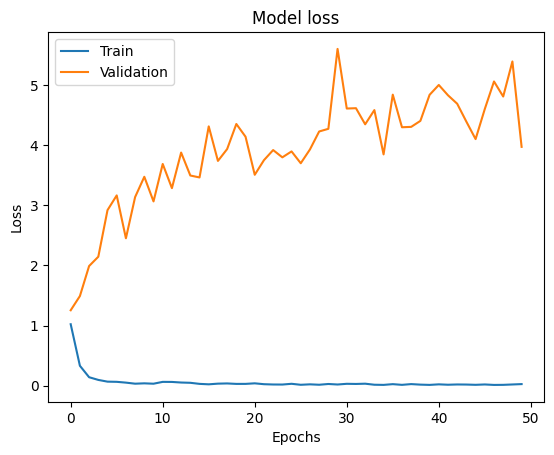

Confusion Matrix:
[[ 82  53   0   0   7   4]
 [ 16 126   1   8  15   3]
 [  1   2   5   1   0   2]
 [  3   6   1  32   3   4]
 [  0  29   0   0   9   1]
 [  4  13   1   8   4  17]]


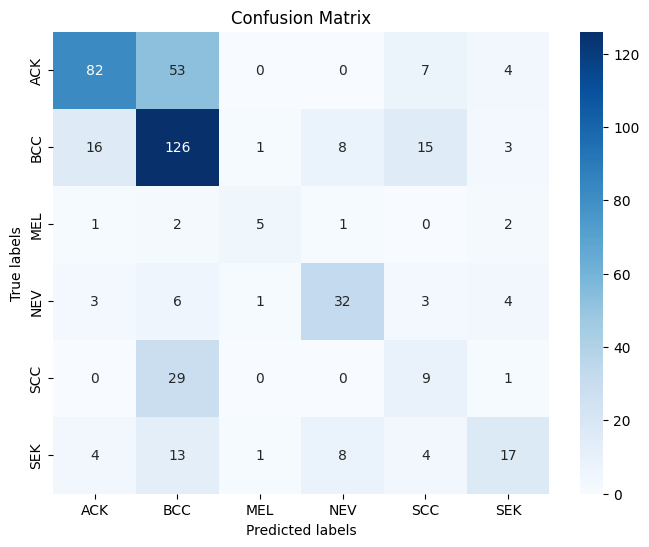


Classification Report:
              precision    recall  f1-score   support

           0     0.7736    0.5616    0.6508       146
           1     0.5502    0.7456    0.6332       169
           2     0.6250    0.4545    0.5263        11
           3     0.6531    0.6531    0.6531        49
           4     0.2368    0.2308    0.2338        39
           5     0.5484    0.3617    0.4359        47

    accuracy                         0.5879       461
   macro avg     0.5645    0.5012    0.5222       461
weighted avg     0.6070    0.5879    0.5844       461



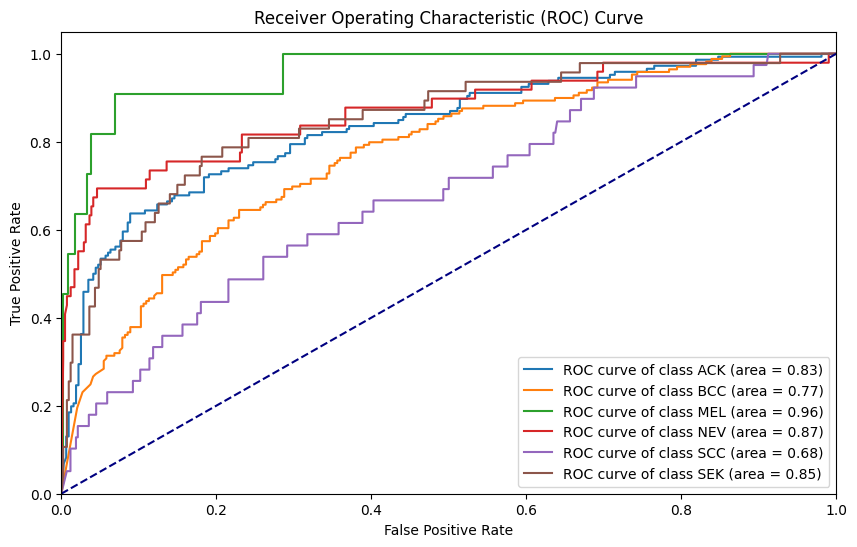

AUC: 0.811
AUC: 0.826


In [ ]:
y_train = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_train.npy')
y_test = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_test.npy')


# Apply PCA for Dimensionality Reduction (Retain 99% Variance)
pca = PCA(n_components=0.99)
x_train_features_pca = pca.fit_transform(x_train_features)
x_test_features_pca = pca.transform(x_test_features)

print(f"Total features after PCA: {x_train_features_pca.shape[1]}")
print("x_train_features_pca",x_train_features_pca.shape)
print("x_test_features_pca",x_test_features_pca.shape)
# print("y_train",y_train.shape)
# print("y_test",y_test.shape)

# y_train_onehot=np.argmax(y_train,axis=1)
# y_test_onehot=np.argmax(y_test,axis=1)
# print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
# print("Shape of y_test_onehot:", y_test_onehot.shape)

model = Sequential([
    Dense(512, activation='relu', input_shape=(1951,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(x_train_features_pca, y_train, epochs=50, batch_size=32, validation_data=(x_test_features_pca,y_test), verbose=0)

# plt.figure(figsize=(12, 5))
# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(x_test_features_pca)  # Get prediction probabilities
np.save('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_prob_pca_pad.npy',y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_pred_pca_pad.npy',y_pred)

# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
num_classes=6
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ---------------------- AUC & ROC Curve ------------------------
y_true = np.argmax(y_test, axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


##MI

###k=500--58.79

Shape of y_train_onehot: (4056,)
Shape of y_test_onehot: (461,)
Original Shape: (4056, 224, 224, 3)
Reduced Shape: (4056, 500)
Original Shape: (461, 224, 224, 3)
Reduced Shape: (461, 500)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


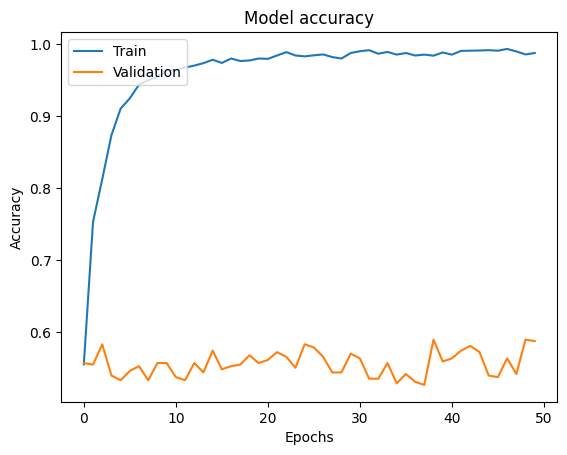

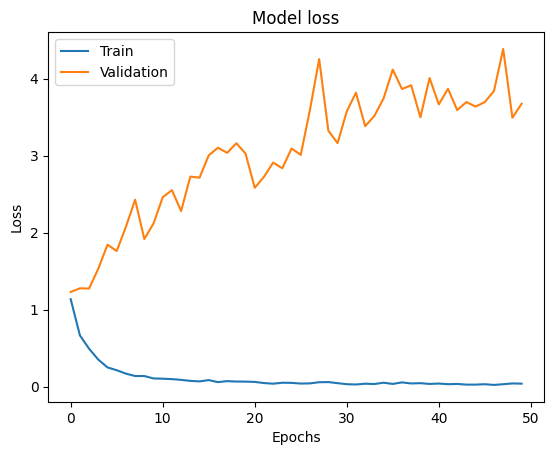

Confusion Matrix:
[[ 77  55   0   0   4  10]
 [  5 131   1  12  14   6]
 [  1   0   7   1   0   2]
 [  3   5   0  29   1  11]
 [  4  29   0   1   5   0]
 [  4  12   0   7   2  22]]


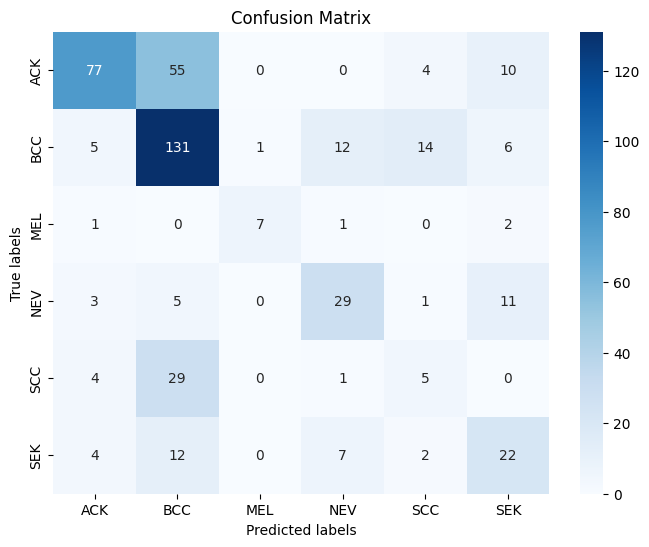


Classification Report:
              precision    recall  f1-score   support

           0     0.8191    0.5274    0.6417       146
           1     0.5647    0.7751    0.6534       169
           2     0.8750    0.6364    0.7368        11
           3     0.5800    0.5918    0.5859        49
           4     0.1923    0.1282    0.1538        39
           5     0.4314    0.4681    0.4490        47

    accuracy                         0.5879       461
   macro avg     0.5771    0.5212    0.5368       461
weighted avg     0.6092    0.5879    0.5814       461



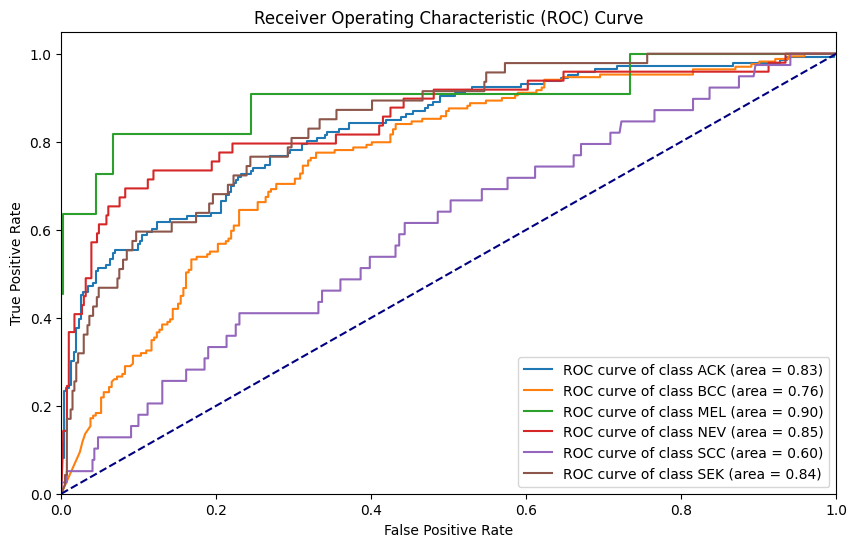

AUC: 0.792
AUC: 0.797


In [ ]:
y_train = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_train.npy')
y_test = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_test.npy')
y_train_onehot=np.argmax(y_train,axis=1)
y_test_onehot=np.argmax(y_test,axis=1)
print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
print("Shape of y_test_onehot:", y_test_onehot.shape)

from sklearn.feature_selection import mutual_info_classif
# Compute Mutual Information Scores
mi_scores = mutual_info_classif(x_train_features_pca, y_train_onehot)

# Get Top-K Important Features (e.g., Select 1000 Best Features)
top_k = 500
selected_features_idx = np.argsort(mi_scores)[-top_k:]  # Indices of top features
X_train_selected_mi = x_train_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_train.shape)  # (4000, 4146)
print("Reduced Shape:", X_train_selected_mi.shape)  # (4000, 1000)

X_test_selected_mi = x_test_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_test.shape)  # (4000, 4146)
print("Reduced Shape:", X_test_selected_mi.shape)  # (4000, 1000)

# Define MLP Model
model = Sequential([
    Dense(512, activation='relu', input_shape=(500,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train_selected_mi, y_train, epochs=50, batch_size=32, validation_data=(X_test_selected_mi, y_test),verbose=0)
# Evaluate on Test Data
# test_loss, test_acc = model.evaluate(x_test_features_pca, y_test)
# print(f"Test Accuracy: {test_acc:.4f}")


# # ---------------------- Plot Accuracy & Loss ------------------------
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# ---------------------- Model Evaluation ------------------------
y_pred_probs =
 model.predict(X_test_selected_mi)  # Get prediction probabilities
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_prob_k500_pad.npy",y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_pred_k500_pad.npy",y_pred)


# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ---------------------- AUC & ROC Curve ------------------------
y_true = np.argmax(y_test, axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)



###k=1000--61.82

Shape of y_train_onehot: (4056,)
Shape of y_test_onehot: (461,)
Original Shape: (4056, 224, 224, 3)
Reduced Shape: (4056, 1000)
Original Shape: (461, 224, 224, 3)
Reduced Shape: (461, 1000)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


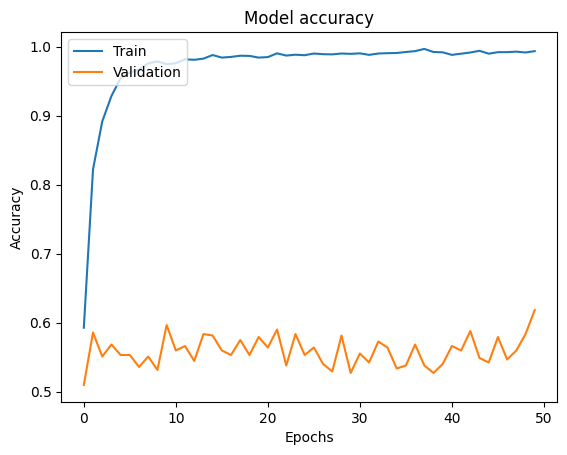

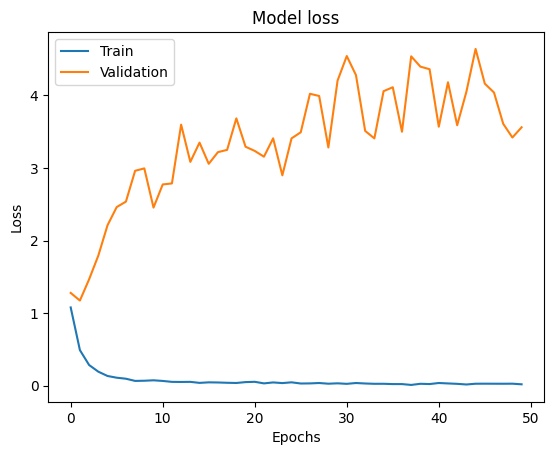

Confusion Matrix:
[[ 79  55   1   0   6   5]
 [ 10 142   0   2  13   2]
 [  0   0   4   0   0   7]
 [  5   8   1  26   1   8]
 [  2  31   0   0   6   0]
 [  2  12   1   2   2  28]]


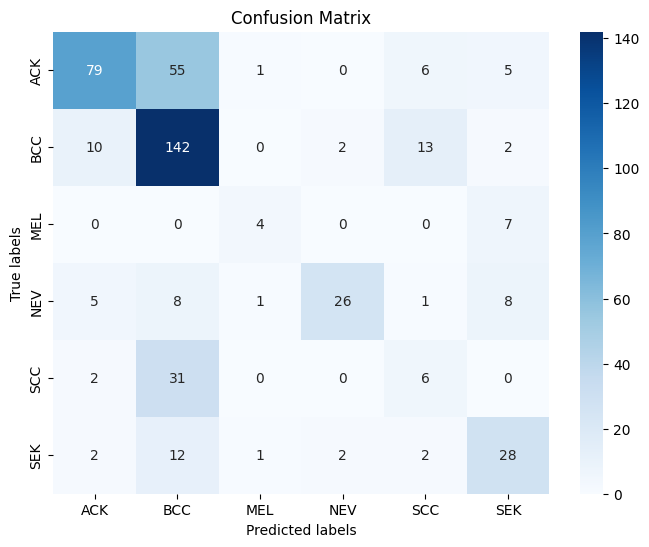


Classification Report:
              precision    recall  f1-score   support

           0     0.8061    0.5411    0.6475       146
           1     0.5726    0.8402    0.6811       169
           2     0.5714    0.3636    0.4444        11
           3     0.8667    0.5306    0.6582        49
           4     0.2143    0.1538    0.1791        39
           5     0.5600    0.5957    0.5773        47

    accuracy                         0.6182       461
   macro avg     0.5985    0.5042    0.5313       461
weighted avg     0.6462    0.6182    0.6093       461



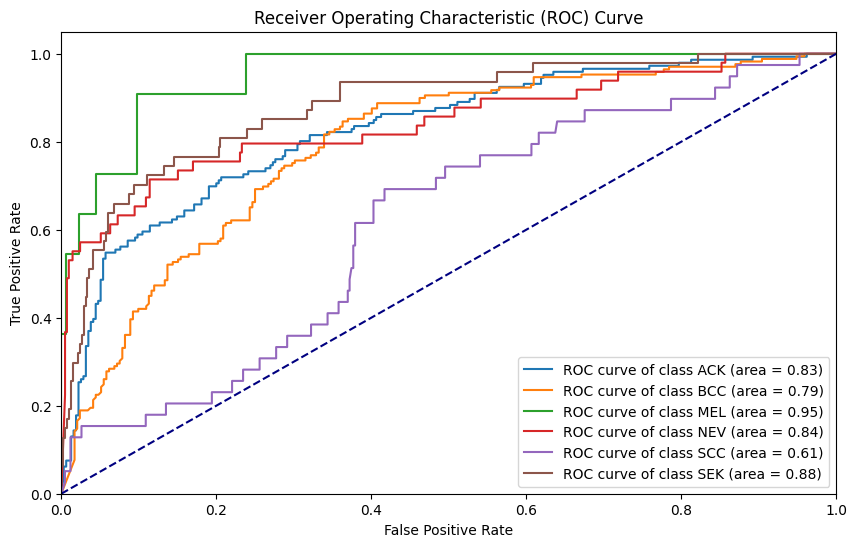

AUC: 0.809
AUC: 0.818


In [ ]:
y_train = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_train.npy')
y_test = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_test.npy')
y_train_onehot=np.argmax(y_train,axis=1)
y_test_onehot=np.argmax(y_test,axis=1)
print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
print("Shape of y_test_onehot:", y_test_onehot.shape)

from sklearn.feature_selection import mutual_info_classif
# Compute Mutual Information Scores
mi_scores = mutual_info_classif(x_train_features_pca, y_train_onehot)

# Get Top-K Important Features (e.g., Select 1000 Best Features)
top_k = 1000
selected_features_idx = np.argsort(mi_scores)[-top_k:]  # Indices of top features
X_train_selected_mi = x_train_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_train.shape)  # (4000, 4146)
print("Reduced Shape:", X_train_selected_mi.shape)  # (4000, 1000)

X_test_selected_mi = x_test_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_test.shape)  # (4000, 4146)
print("Reduced Shape:", X_test_selected_mi.shape)  # (4000, 1000)

# Define MLP Model
model = Sequential([
    Dense(512, activation='relu', input_shape=(1000,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train_selected_mi, y_train, epochs=50, batch_size=32, validation_data=(X_test_selected_mi, y_test),verbose=0)

# Evaluate on Test Data
# test_loss, test_acc = model.evaluate(x_test_features_pca, y_test)
# print(f"Test Accuracy: {test_acc:.4f}")


# ---------------------- Plot Accuracy & Loss ------------------------
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(X_test_selected_mi)  # Get prediction probabilities
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_prob_k1000_pad.npy",y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_pred_k1000_pad.npy",y_pred)


# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ---------------------- AUC & ROC Curve ------------------------
y_true = np.argmax(y_test, axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


###k=1500--58.79

Shape of y_train_onehot: (4056,)
Shape of y_test_onehot: (461,)
Original Shape: (4056, 224, 224, 3)
Reduced Shape: (4056, 1500)
Original Shape: (461, 224, 224, 3)
Reduced Shape: (461, 1500)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


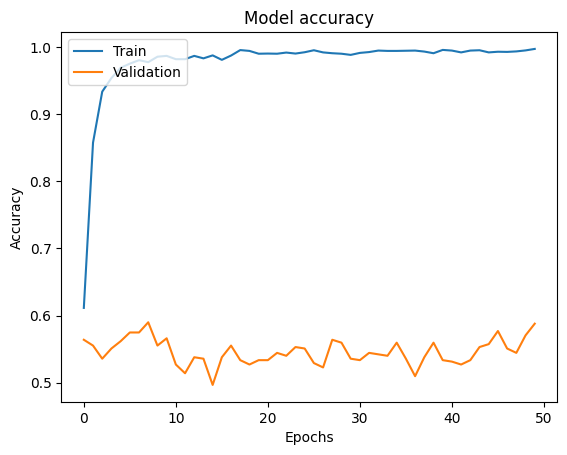

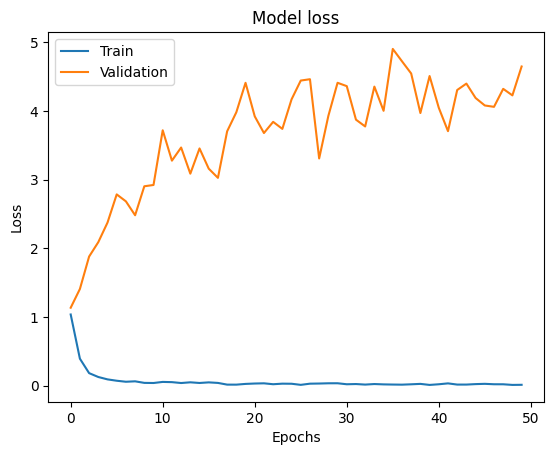

Confusion Matrix:
[[ 65  68   1   3   5   4]
 [  9 141   0   8   8   3]
 [  0   3   3   1   0   4]
 [  1   4   2  34   3   5]
 [  1  29   0   0   9   0]
 [  0  19   0   6   3  19]]


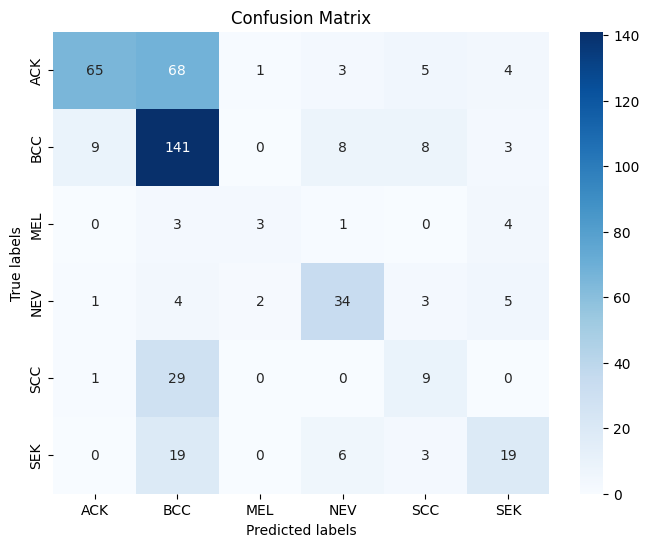


Classification Report:
              precision    recall  f1-score   support

           0     0.8553    0.4452    0.5856       146
           1     0.5341    0.8343    0.6513       169
           2     0.5000    0.2727    0.3529        11
           3     0.6538    0.6939    0.6733        49
           4     0.3214    0.2308    0.2687        39
           5     0.5429    0.4043    0.4634        47

    accuracy                         0.5879       461
   macro avg     0.5679    0.4802    0.4992       461
weighted avg     0.6306    0.5879    0.5742       461



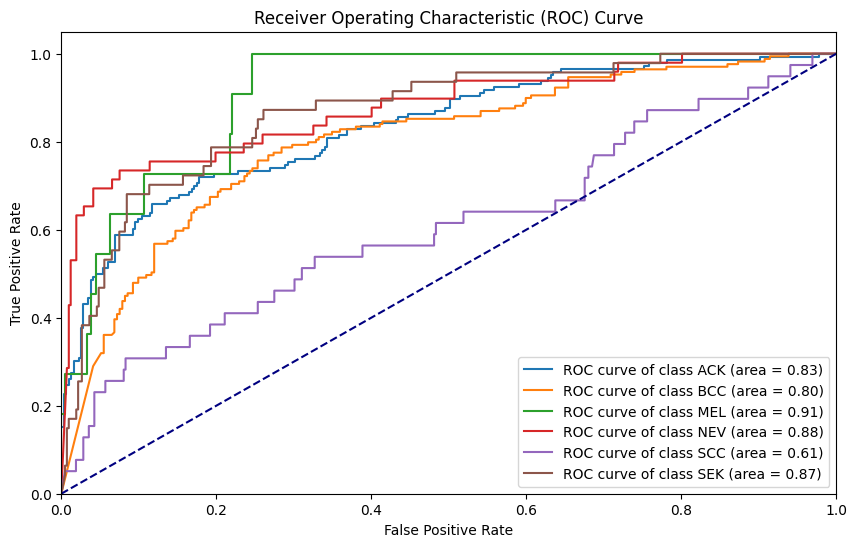

AUC: 0.801
AUC: 0.816


In [ ]:
y_train = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_train.npy')
y_test = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_test.npy')
y_train_onehot=np.argmax(y_train,axis=1)
y_test_onehot=np.argmax(y_test,axis=1)
print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
print("Shape of y_test_onehot:", y_test_onehot.shape)

from sklearn.feature_selection import mutual_info_classif
# Compute Mutual Information Scores
mi_scores = mutual_info_classif(x_train_features_pca, y_train_onehot)

# Get Top-K Important Features (e.g., Select 1000 Best Features)
top_k = 1500
selected_features_idx = np.argsort(mi_scores)[-top_k:]  # Indices of top features
X_train_selected_mi = x_train_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_train.shape)  # (4000, 4146)
print("Reduced Shape:", X_train_selected_mi.shape)  # (4000, 1000)

X_test_selected_mi = x_test_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_test.shape)  # (4000, 4146)
print("Reduced Shape:", X_test_selected_mi.shape)  # (4000, 1000)

# Define MLP Model
model = Sequential([
    Dense(512, activation='relu', input_shape=(1500,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train_selected_mi, y_train, epochs=50, batch_size=32, validation_data=(X_test_selected_mi, y_test),verbose=0)

# Evaluate on Test Data
# test_loss, test_acc = model.evaluate(x_test_features_pca, y_test)
# print(f"Test Accuracy: {test_acc:.4f}")


# ---------------------- Plot Accuracy & Loss ------------------------
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(X_test_selected_mi)  # Get prediction probabilities
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_prob_k1500_pad.npy",y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_pred_k1500_pad.npy",y_pred)


# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ---------------------- AUC & ROC Curve ------------------------
y_true = np.argmax(y_test, axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


###k=1750--63.99

Shape of y_train_onehot: (4056,)
Shape of y_test_onehot: (461,)
Original Shape: (4056, 224, 224, 3)
Reduced Shape: (4056, 1750)
Original Shape: (461, 224, 224, 3)
Reduced Shape: (461, 1750)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


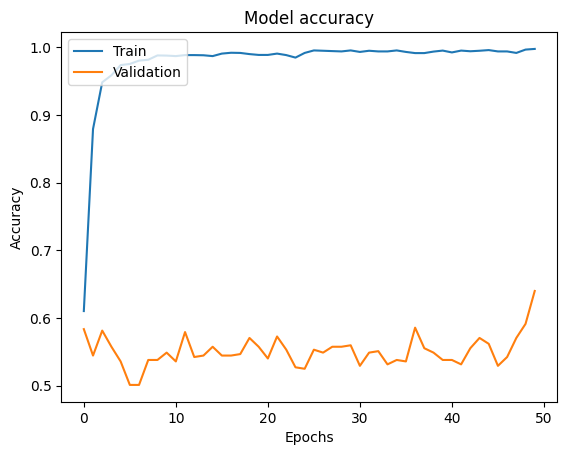

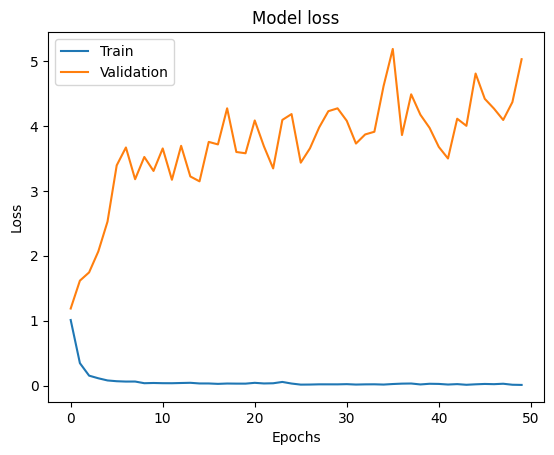

Confusion Matrix:
[[ 79  58   0   0   2   7]
 [  9 151   1   3   3   2]
 [  0   1   6   1   0   3]
 [  1   8   1  28   0  11]
 [  1  31   0   1   6   0]
 [  3  18   0   0   1  25]]


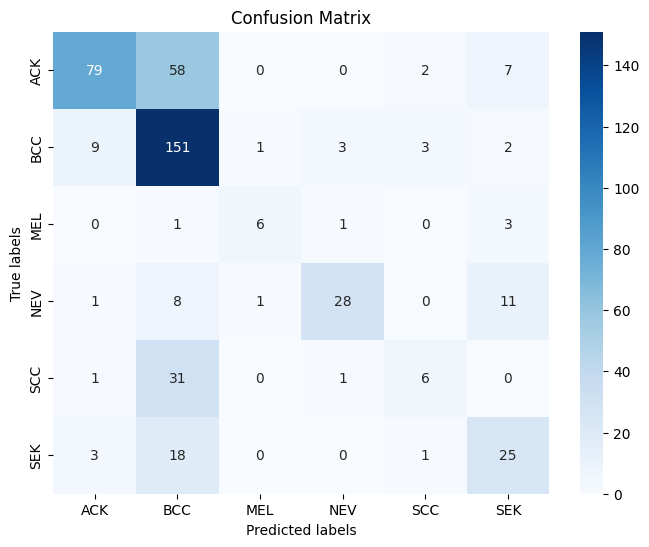


Classification Report:
              precision    recall  f1-score   support

           0     0.8495    0.5411    0.6611       146
           1     0.5655    0.8935    0.6927       169
           2     0.7500    0.5455    0.6316        11
           3     0.8485    0.5714    0.6829        49
           4     0.5000    0.1538    0.2353        39
           5     0.5208    0.5319    0.5263        47

    accuracy                         0.6399       461
   macro avg     0.6724    0.5395    0.5716       461
weighted avg     0.6798    0.6399    0.6245       461



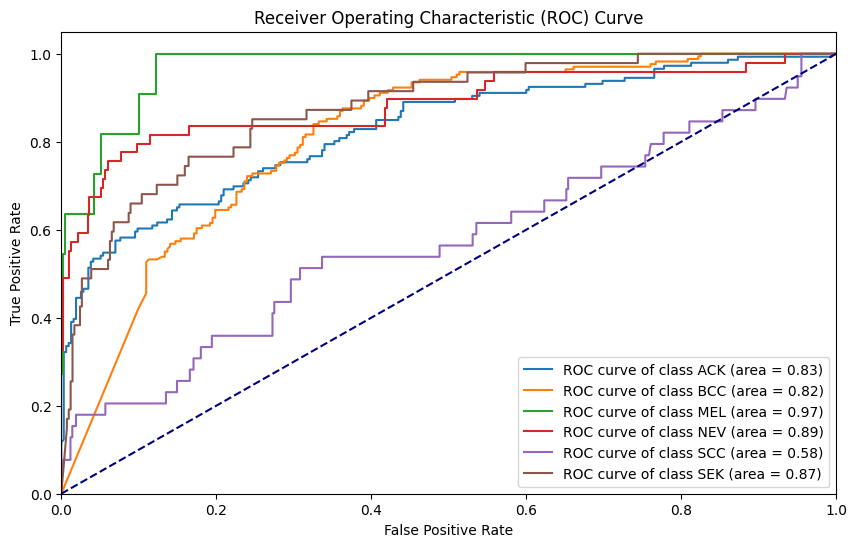

AUC: 0.801
AUC: 0.825


In [ ]:
y_train = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_train.npy')
y_test = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_test.npy')
y_train_onehot=np.argmax(y_train,axis=1)
y_test_onehot=np.argmax(y_test,axis=1)
print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
print("Shape of y_test_onehot:", y_test_onehot.shape)

from sklearn.feature_selection import mutual_info_classif
# Compute Mutual Information Scores
mi_scores = mutual_info_classif(x_train_features_pca, y_train_onehot)

# Get Top-K Important Features (e.g., Select 1000 Best Features)
top_k = 1750
selected_features_idx = np.argsort(mi_scores)[-top_k:]  # Indices of top features
X_train_selected_mi = x_train_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_train.shape)  # (4000, 4146)
print("Reduced Shape:", X_train_selected_mi.shape)  # (4000, 1000)

X_test_selected_mi = x_test_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_test.shape)  # (4000, 4146)
print("Reduced Shape:", X_test_selected_mi.shape)  # (4000, 1000)

# Define MLP Model
model = Sequential([
    Dense(512, activation='relu', input_shape=(1750,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train_selected_mi, y_train, epochs=50, batch_size=32, validation_data=(X_test_selected_mi, y_test),verbose=0)

# Evaluate on Test Data
# test_loss, test_acc = model.evaluate(x_test_features_pca, y_test)
# print(f"Test Accuracy: {test_acc:.4f}")


# ---------------------- Plot Accuracy & Loss ------------------------
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(X_test_selected_mi)  # Get prediction probabilities
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_prob_k1750_pad.npy",y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_pred_k1750_pad.npy",y_pred)


# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ---------------------- AUC & ROC Curve ------------------------
y_true = np.argmax(y_test, axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


#majority voting--81.78

In [ ]:
from scipy.stats import mode

# Load predictions from .npy files
m1x = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/gnet/x_test_pred_gnet_pad.npy')
m2x = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dnet/x_test_pred_dnet_pad.npy')
m3x = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mnet/x_test_pred_mnet_pad.npy')
m4x = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/nnet/x_test_pred_nnet_pad.npy')
m5x = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/irnet/x_test_pred_irnet_pad.npy')
m6x = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/ccnngru/x_test_pred_ccnngru_pad.npy')
m7x = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/svm/x_test_pred_svm_pad.npy')
m8x = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_prob_k1750_pad.npy')
m8x=np.argmax(m8x,axis=1)
print("m1x shape=",m1x.shape)
print("m2x shape=",m2x.shape)
print("m3x shape=",m3x.shape)
print("m4x shape=",m4x.shape)
print("m5x shape=",m5x.shape)
print("m6x shape=",m6x.shape)
print("m7x shape=",m7x.shape)
print("m8x shape=",m8x.shape)



# Stack predictions to shape (num_samples, 3)
all_predictions = np.vstack((m1x,m2x,m3x,m4x,m5x,m6x,m7x,m8x))  # Transpose to get (num_samples, 3)


# Apply Majority Voting - Get the most frequent class in each row
final_predictions, _ = mode(all_predictions, axis=1, keepdims=False)

# If ground truth labels are available, evaluate accuracy
y_test = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_test.npy')



y_test_labels= np.argmax(y_test, axis=1)
# Store models in a list
models = [m1x, m2x, m3x, m4x, m5x, m6x,m7x,m8x]
model_names = ['m1', 'm2', 'm3', 'm4', 'm5', 'm6','m7','m8']

# Generate all possible combinations of 2, 3, 4, and 5 models
best_accuracy = 0
best_combination = None

for r in range(2, 9):  # From 2-model to 5-model combinations
    for combo in combinations(range(8), r):  # Get index combinations
        selected_models = [models[i] for i in combo]
        selected_names = [model_names[i] for i in combo]

        # Stack selected models and apply majority voting
        all_predictions = np.vstack(selected_models).T  # Shape (num_samples, r)
        final_predictions, _ = mode(all_predictions, axis=1, keepdims=False)

        # Compute accuracy
        accuracy = accuracy_score(y_test_labels, final_predictions)

        # Print result
        print(f"Combination: {selected_names}, Test Accuracy: {accuracy * 100:.2f}%")

        # Track best combination
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_combination = selected_names

# Print best model combination
print("\nBest Combination:", best_combination, f"with Accuracy: {best_accuracy * 100:.2f}%")

m1x shape= (461,)
m2x shape= (461,)
m3x shape= (461,)
m4x shape= (461,)
m5x shape= (461,)
m6x shape= (461,)
m7x shape= (461,)
m8x shape= (461,)
Combination: ['m1', 'm2'], Test Accuracy: 68.98%
Combination: ['m1', 'm3'], Test Accuracy: 63.34%
Combination: ['m1', 'm4'], Test Accuracy: 60.30%
Combination: ['m1', 'm5'], Test Accuracy: 60.52%
Combination: ['m1', 'm6'], Test Accuracy: 71.80%
Combination: ['m1', 'm7'], Test Accuracy: 70.50%
Combination: ['m1', 'm8'], Test Accuracy: 65.08%
Combination: ['m2', 'm3'], Test Accuracy: 70.07%
Combination: ['m2', 'm4'], Test Accuracy: 67.90%
Combination: ['m2', 'm5'], Test Accuracy: 69.20%
Combination: ['m2', 'm6'], Test Accuracy: 77.87%
Combination: ['m2', 'm7'], Test Accuracy: 75.70%
Combination: ['m2', 'm8'], Test Accuracy: 71.15%
Combination: ['m3', 'm4'], Test Accuracy: 60.52%
Combination: ['m3', 'm5'], Test Accuracy: 62.04%
Combination: ['m3', 'm6'], Test Accuracy: 74.62%
Combination: ['m3', 'm7'], Test Accuracy: 73.10%
Combination: ['m3', 'm8

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Full model name mapping
model_names = {
    'M1': 'GoogleNet',
    'M2': 'DenseNet201',
    'M3': 'MobileNetV2',
    'M4': 'NASNet',
    'M5': 'InceptionResNetV2',
    'M6': 'PHMBCNNGRU',
    'M7': 'SVM',
    'M8': 'MLP'

}
# Your dictionary
data = {

    2: {68.98, 63.34, 60.30, 60.52, 71.80, 70.50, 65.08, 70.07, 67.90, 69.20, 77.87, 75.70, 71.15, 60.52, 62.04, 74.62, 73.10, 64.21, 61.39, 71.58, 71.37, 64.43, 74.40, 73.10, 65.08, 79.61, 76.14, 74.19},
    3: {67.03, 68.76, 65.73, 78.31, 77.22, 68.98, 63.77, 61.82, 70.50, 70.28,
            62.69, 62.91, 72.02, 71.15, 64.21, 71.37, 70.28, 63.99, 80.91, 74.40,
            73.54, 68.11, 66.38, 76.36, 75.49, 67.46, 66.81, 75.27, 74.19, 68.76,
            77.22, 76.36, 68.98, 81.34, 79.18, 78.09, 63.77, 72.02, 71.58, 62.91,
            70.28, 69.63, 64.86, 81.34, 72.67, 71.80, 70.72, 69.63, 64.86, 80.04,
            73.75, 72.89, 80.04, 73.32, 71.80, 81.78},
    4:{68.33, 67.68, 76.57, 75.92, 68.76, 67.03, 74.84, 73.97, 69.41, 75.27,
            74.84, 68.55, 79.39, 76.79, 76.14, 63.99, 70.28, 70.07, 66.81, 70.72,
            70.28, 64.64, 78.74, 73.54, 72.23, 70.50, 69.85, 65.29, 77.87, 73.54,
            72.23, 78.74, 72.67, 72.23, 78.09, 68.55, 76.14, 75.05, 70.50, 76.14,
            74.84, 69.41, 79.83, 77.87, 76.79, 74.84, 73.75, 69.63, 79.39, 76.79,
            75.49, 79.18, 77.22, 76.14, 81.56, 71.80, 71.15, 66.16, 79.39, 74.19,
            73.54, 78.96, 72.89, 72.45, 80.26, 78.09, 73.97, 73.10, 80.26, 78.31},
    5:{67.25, 74.40, 73.54, 67.03, 71.37, 70.93, 66.59, 78.52, 74.19, 73.54,
             72.89, 72.45, 67.68, 78.96, 75.92, 75.49, 79.83, 74.84, 73.75, 80.26,
             68.11, 67.90, 64.64, 75.05, 69.63, 69.41, 75.27, 68.76, 68.76, 76.36,
             75.92, 69.85, 69.63, 77.87, 75.92, 72.23, 72.23, 68.55, 77.87, 75.05,
             74.62, 78.96, 73.10, 72.67, 80.69, 78.74, 74.62, 73.97, 79.83, 79.18,
             74.84, 70.28, 70.07, 77.87, 75.49, 76.14},
    6:{72.02, 71.15, 68.33, 78.09, 73.97, 72.89, 78.52, 72.89, 71.80, 79.61,
             77.22, 73.54, 72.23, 78.52, 78.96, 74.40, 69.20, 68.98, 75.92, 76.36,
             75.70, 77.44, 73.54, 72.89, 79.61, 78.52, 77.87, 76.36},
    7:{75.05, 71.15, 70.28, 77.66, 76.14, 77.22, 72.45, 76.14},
    8:{74.62}
}

# Convert to DataFrame
rows = []
for key, values in data.items():
    for val in values:
        rows.append({'Key': key, 'Value': val})

df = pd.DataFrame(rows)

# Find the max value
max_val = df['Value'].max()

# Add color column
df['Color'] = df['Value'].apply(lambda x: 'red' if x == max_val else 'skyblue')

# Plot
plt.figure(figsize=(10,5), dpi=300)
for i, row in df.iterrows():
    plt.scatter(row['Key'], row['Value'], color=row['Color'], s=75)
                # , edgecolor='black')
    if row['Color'] == 'red':
        plt.text(row['Key'], row['Value'] + 0.4, f"{{M6,M7,M8}} = {row['Value']}%",
                 ha='center', va='bottom', fontsize=12, color='red')
# Set x-axis to show only unique keys
plt.xticks(sorted(data.keys()), fontsize=10)
plt.yticks(range(58, 86, 2),fontsize=10)
plt.ylim(58, 86)

# Combined legend text box
legend_text = "Legend:\n• Best Combination (red dot)\n\nModel Names:\n" + '\n'.join([f"{k} = {v}" for k, v in model_names.items()])
plt.gcf().text(0.79, 0.15, legend_text, fontsize=8.5, va='bottom', bbox=dict(facecolor='white', edgecolor='gray'))

# Labels & layout
# plt.title('Strip Plot (Highlight Highest Value)')
plt.xlabel("Number of Models in Combination", fontsize=10)
plt.ylabel("Accuracy (%)", fontsize=10)
plt.title("SVM classifier Accuracy Visualization on Model Combinations", fontsize=12, weight='bold')
# plt.xlabel('Key')
# plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


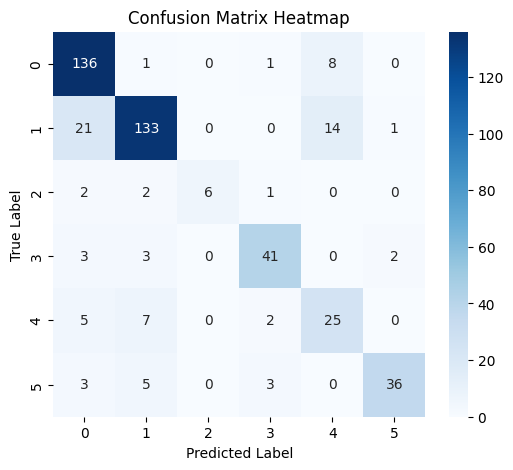

Classification Report:
               precision    recall  f1-score   support

           0     0.8000    0.9315    0.8608       146
           1     0.8808    0.7870    0.8313       169
           2     1.0000    0.5455    0.7059        11
           3     0.8542    0.8367    0.8454        49
           4     0.5319    0.6410    0.5814        39
           5     0.9231    0.7660    0.8372        47

    accuracy                         0.8178       461
   macro avg     0.8317    0.7513    0.7770       461
weighted avg     0.8300    0.8178    0.8186       461

Accuracy: 0.8178
Precision: 0.8300, Recall: 0.8178, F1-score: 0.8186
Matthews Correlation Coefficient: 0.7545
Cohen's Kappa Score: 0.7519


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, cohen_kappa_score, matthews_corrcoef

m6x = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/ccnngru/x_test_pred_ccnngru_pad.npy')
m7x = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/svm/x_test_pred_svm_pad.npy')
m8x = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/mlp/x_test_prob_k1750_pad.npy')
m8x=np.argmax(m8x,axis=1)

# Stack predictions to shape (num_samples, 3)
all_predictions = np.vstack((m6x,m7x,m8x))  # Transpose to get (num_samples, 3)


# Apply Majority Voting - Get the most frequent class in each row
# final_predictions, _ = mode(all_predictions, axis=1, keepdims=False)
final_preds = np.array([np.bincount(preds).argmax() for preds in zip(m6x,m7x,m8x)])


# If ground truth labels are available, evaluate accuracy
y_test = np.load('/content/drive/MyDrive/PAD_UFES_20/paper4/dataset/y_test.npy')
y_true= np.argmax(y_test, axis=1)

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_true, final_preds)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(y_true, final_preds,digits=4))

# Performance Metrics
accuracy = accuracy_score(y_true, final_preds)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, final_preds, average='weighted')
# conf_matrix = confusion_matrix(y_true, final_preds)
mcc = matthews_corrcoef(y_true, final_preds)
cohen_kappa = cohen_kappa_score(y_true, final_preds)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
# print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
print(f"Cohen's Kappa Score: {cohen_kappa:.4f}")

